In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/muhammadwajdan/brain-tumor-segmentation-hybrid-danet/pytorch/phase-135/1/hybrid_danet_best.pth
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/name_mapping_validation_data.csv
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/survival_evaluation.csv
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Validation_084_flair.nii
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Validation_084_t2.nii
/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Validation_084_t1ce.nii
/kaggle/input/datasets/awsaf49/brats20-data

## Phase 0 : INITIALIZATION

In [2]:
!pip install nibabel medpy tqdm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
# ──Imports ────────────────────────────────────────────────────────

import os
import random
import math
import time
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
 
from tqdm.notebook import tqdm

In [4]:
# ──Reproducibility & device setup ─────────────────────────────────
SEED = 42
 
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False   # set True later for speed if shapes are fixed
 
set_seed()
 
# Detect GPUs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus = torch.cuda.device_count()
 
print("=" * 55)
print(f"  Device      : {device}")
print(f"  # GPUs      : {n_gpus}")
for i in range(n_gpus):
    props = torch.cuda.get_device_properties(i)
    mem_gb = props.total_memory / 1024**3
    print(f"  GPU {i}       : {props.name}  ({mem_gb:.1f} GB)")
print("=" * 55)
 

  Device      : cuda
  # GPUs      : 2
  GPU 0       : Tesla T4  (14.6 GB)
  GPU 1       : Tesla T4  (14.6 GB)


In [5]:
import os

# ── Global constants ───────────────────────────────────────────────
# Paths updated to point to the actual folder containing patient subdirectories
BASE_DIR  = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation"

# These paths must point to the 'MICCAI' folders to find the 'BraTS20_...' subfolders
TRAIN_DIR = os.path.join(BASE_DIR, "BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")
VAL_DIR   = os.path.join(BASE_DIR, "BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData")

# Modality order (must stay consistent everywhere)
MODALITIES  = ["flair", "t1", "t1ce", "t2"]   # 4 input channels

# Paper patch size (D × H × W)
# Standardized to 128x128x128 for T4 GPU memory efficiency, or 128x160x192 as per your requirement
PATCH_D, PATCH_H, PATCH_W = 128, 128, 128 

# BraTS label mapping
NUM_CLASSES = 3

# Training split 
TRAIN_FRAC = 0.80

# DataLoader settings for Dual T4 GPUs
# Batch size 2 is required to utilize both GPUs (1 volume per GPU)
BATCH_SIZE  = 2      
NUM_WORKERS = 4

print(f"Checking Training Path: {os.path.exists(TRAIN_DIR)}")
print(f"Checking Validation Path: {os.path.exists(VAL_DIR)}")
print(f"Batch size  : {BATCH_SIZE}")
print("Phase 0 ✓")

Checking Training Path: True
Checking Validation Path: True
Batch size  : 2
Phase 0 ✓


## Phase 1: DATASET LOADING and EXPLORING

In [6]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║               PHASE 1 — DATASET EXPLORATION & VERIFICATION              ║
# ╚══════════════════════════════════════════════════════════════════════════╝
 
# ── Cell 1-A : Scan folders and count patients ────────────────────────────────
def get_patient_folders(directory: str) -> list:
    """Return sorted list of patient folder names that start with 'BraTS20'."""
    if not os.path.exists(directory):
        print(f"[WARNING] Directory not found: {directory}")
        return []
    patients = [
        f for f in os.listdir(directory)
        if f.startswith("BraTS20") and os.path.isdir(os.path.join(directory, f))
    ]
    return sorted(patients)
 
train_patients = get_patient_folders(TRAIN_DIR)
val_patients   = get_patient_folders(VAL_DIR)
 
print("=" * 55)
print(f"  Training patients   : {len(train_patients)}")
print(f"  Validation patients : {len(val_patients)}")
print("=" * 55)
 
# Sanity-check first patient
if train_patients:
    sample_id   = train_patients[0]
    sample_path = os.path.join(TRAIN_DIR, sample_id)
    files       = sorted(os.listdir(sample_path))
    print(f"\nContents of '{sample_id}':")
    for f in files:
        print(f"  {f}")

  Training patients   : 369
  Validation patients : 125

Contents of 'BraTS20_Training_001':
  BraTS20_Training_001_flair.nii
  BraTS20_Training_001_seg.nii
  BraTS20_Training_001_t1.nii
  BraTS20_Training_001_t1ce.nii
  BraTS20_Training_001_t2.nii


In [7]:
# ──Load one patient and inspect NIfTI metadata ───────────────────
def load_patient(patient_id: str, base_dir: str = TRAIN_DIR) -> dict:
    """
    Load all 4 modalities + segmentation mask for one patient.
    Returns dict: {modality_name: np.ndarray, ..., 'seg': np.ndarray}
    """
    patient_path = os.path.join(base_dir, patient_id)
    data = {}
 
    for mod in MODALITIES:
        # Pattern: BraTS20_Training_001_flair.nii
        fname = f"{patient_id}_{mod}.nii"
        fpath = os.path.join(patient_path, fname)
        if not os.path.exists(fpath):
            fpath += ".gz"                          # try gzipped version
        img = nib.load(fpath)
        data[mod] = img.get_fdata(dtype=np.float32)
 
    # Segmentation mask
    seg_fname = f"{patient_id}_seg.nii"
    seg_path  = os.path.join(patient_path, seg_fname)
    if not os.path.exists(seg_path):
        seg_path += ".gz"
    seg_img   = nib.load(seg_path)
    data["seg"] = seg_img.get_fdata(dtype=np.float32).astype(np.int16)
 
    return data
 
# Load first patient
print("Loading first patient …")
sample_data = load_patient(train_patients[0])
 
print("\n── Volume Metadata ──")
print(f"{'Modality':<10} {'Shape':<20} {'Min':>8} {'Max':>8} {'Mean':>10} {'Std':>10}")
print("-" * 68)
for key, arr in sample_data.items():
    print(f"{key:<10} {str(arr.shape):<20} {arr.min():>8.1f} {arr.max():>8.1f} "
          f"{arr.mean():>10.3f} {arr.std():>10.3f}")

Loading first patient …

── Volume Metadata ──
Modality   Shape                     Min      Max       Mean        Std
--------------------------------------------------------------------
flair      (240, 240, 155)           0.0    625.0     26.022     66.765
t1         (240, 240, 155)           0.0    678.0     53.287    130.785
t1ce       (240, 240, 155)           0.0   1845.0     62.772    155.079
t2         (240, 240, 155)           0.0    376.0     17.251     44.979
seg        (240, 240, 155)           0.0      4.0      0.052      0.353


In [8]:
# ──Label distribution for one patient ────────────────────────────
seg = sample_data["seg"]
unique_labels, counts = np.unique(seg, return_counts=True)
total_voxels = seg.size
 
print("\n── Segmentation Label Distribution (single patient) ──")
label_names = {0: "Background", 1: "NCR/NET", 2: "Edema", 4: "Enhancing Tumor"}
for lbl, cnt in zip(unique_labels, counts):
    name = label_names.get(int(lbl), f"Label {lbl}")
    print(f"  {name:<20}: {cnt:>8,}  ({100*cnt/total_voxels:.4f}%)")
 


── Segmentation Label Distribution (single patient) ──
  Background          : 8,716,021  (97.6257%)
  NCR/NET             :   15,443  (0.1730%)
  Edema               :  168,794  (1.8906%)
  Enhancing Tumor     :   27,742  (0.3107%)


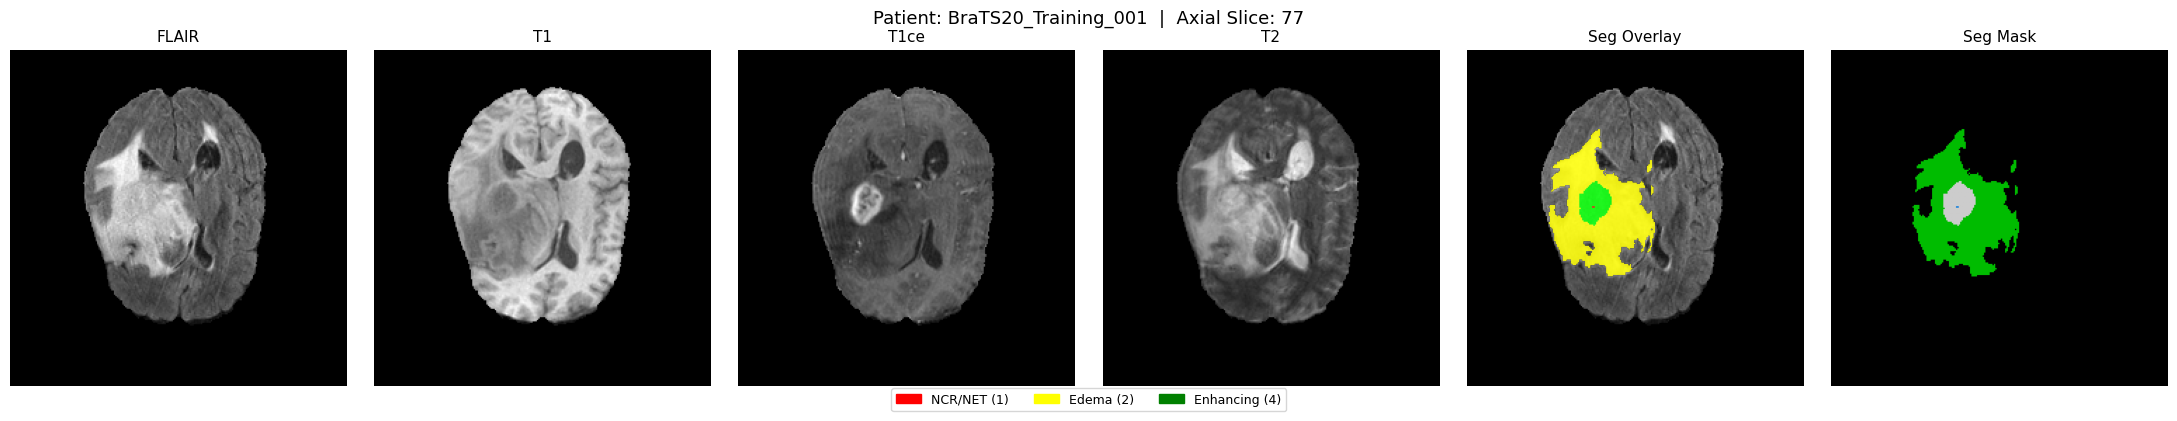

Visualized axial slice 77 / 154

Showing 5 consecutive slices around tumor centre …


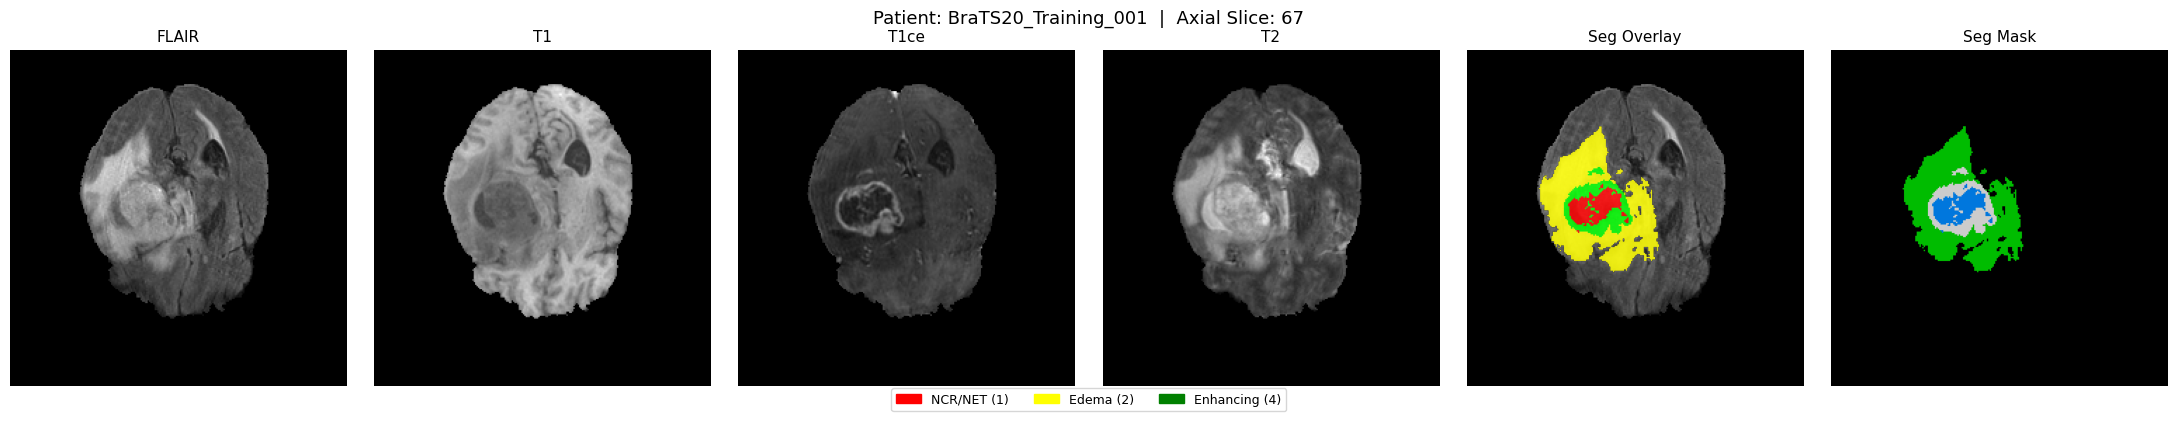

Visualized axial slice 67 / 154


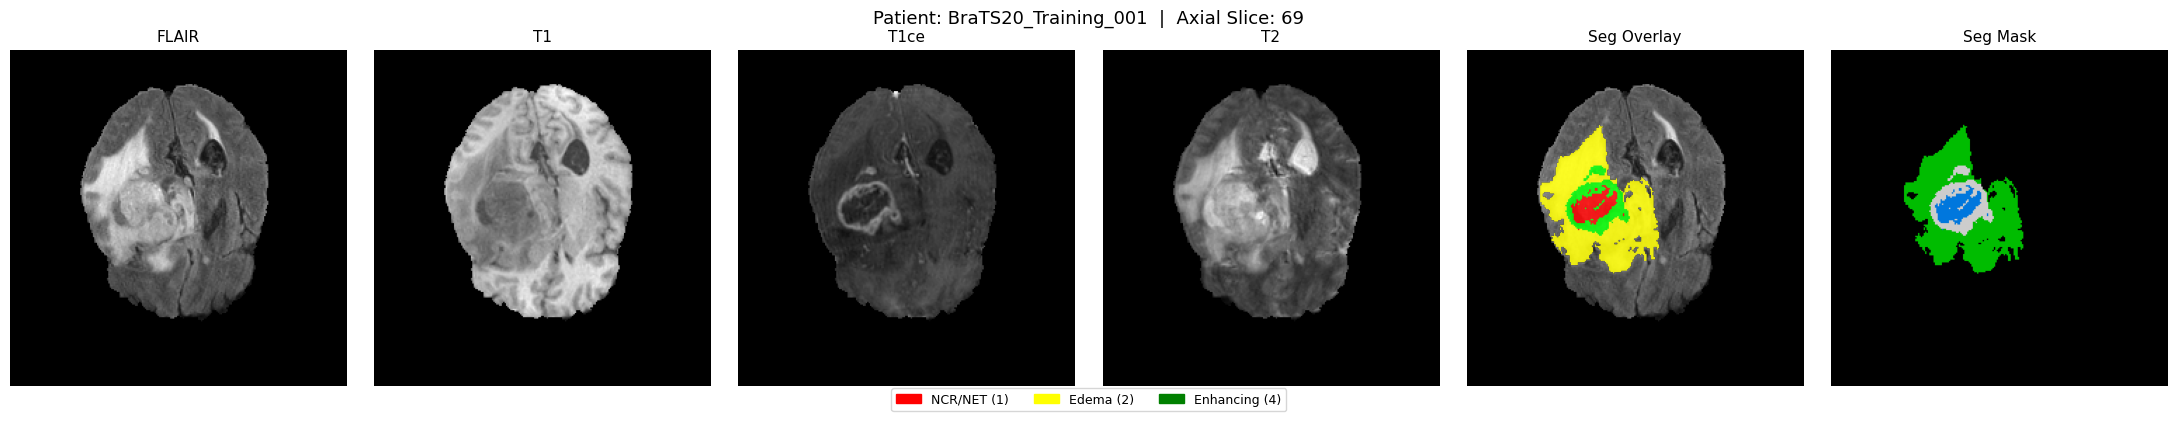

Visualized axial slice 69 / 154


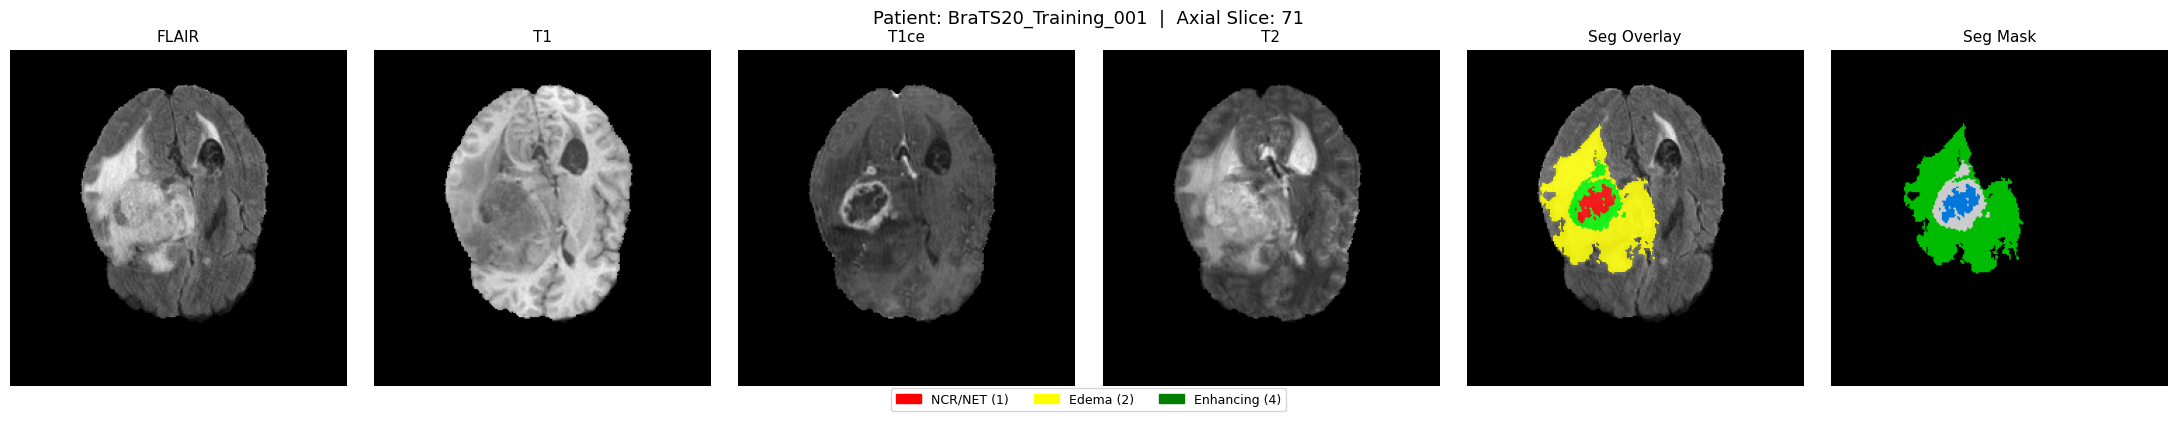

Visualized axial slice 71 / 154


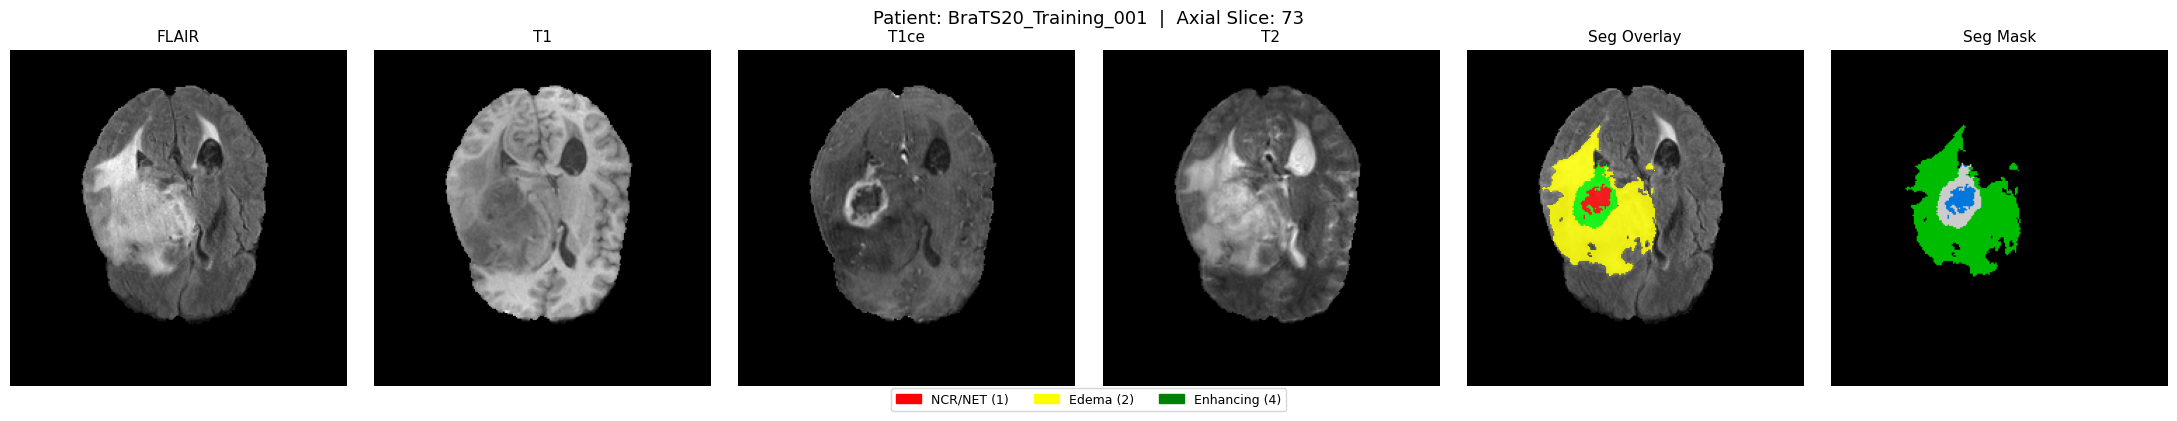

Visualized axial slice 73 / 154


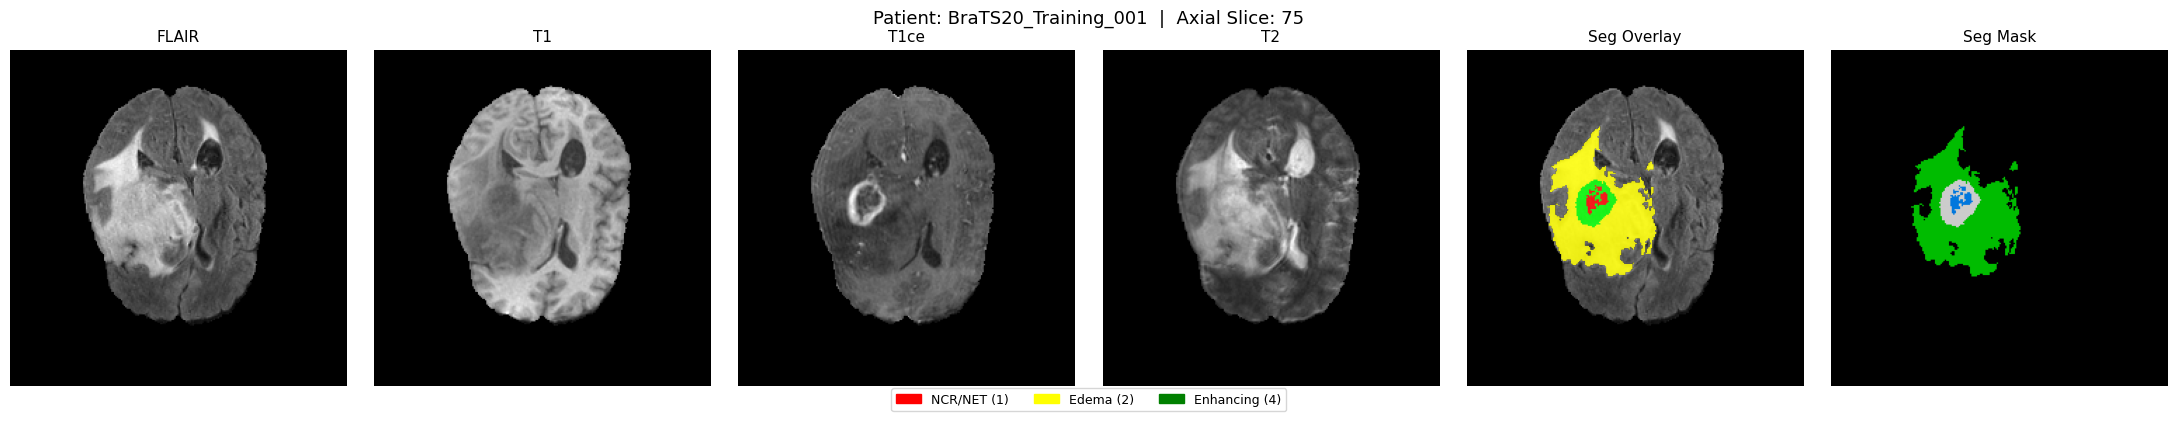

Visualized axial slice 75 / 154


In [9]:
# ──Visualize all 4 modalities + segmentation mask ─────────────────
def visualize_patient(data: dict, patient_id: str = "Sample", slice_idx: int = None):
    """
    Plot mid-axial slice for each of the 4 modalities + segmentation overlay.
    Colors: NCR/NET=red, Edema=yellow, EnhancingTumor=green
    """
    vol_shape = data["flair"].shape              # (H, W, D)
    if slice_idx is None:
        slice_idx = vol_shape[2] // 2            # mid-axial slice
 
    fig, axes = plt.subplots(1, 6, figsize=(22, 4))
    fig.suptitle(f"Patient: {patient_id}  |  Axial Slice: {slice_idx}", fontsize=13)
 
    mod_labels = ["FLAIR", "T1", "T1ce", "T2"]
    cmaps      = ["gray", "gray", "gray", "gray"]
 
    for i, (mod, cmap) in enumerate(zip(MODALITIES, cmaps)):
        sl = data[mod][:, :, slice_idx]
        axes[i].imshow(sl.T, cmap=cmap, origin="lower")
        axes[i].set_title(mod_labels[i], fontsize=11)
        axes[i].axis("off")
 
    # --- Segmentation mask (col 5) ---
    seg_sl = data["seg"][:, :, slice_idx].T
    color_mask = np.zeros((*seg_sl.shape, 4), dtype=np.float32)     # RGBA
    # NCR/NET   → red
    color_mask[seg_sl == 1] = [1.0, 0.0, 0.0, 0.85]
    # Edema     → yellow
    color_mask[seg_sl == 2] = [1.0, 1.0, 0.0, 0.85]
    # Enhancing → green
    color_mask[seg_sl == 4] = [0.0, 1.0, 0.0, 0.85]
 
    flair_bg = data["flair"][:, :, slice_idx].T
    axes[4].imshow(flair_bg, cmap="gray", origin="lower")
    axes[4].imshow(color_mask, origin="lower")
    axes[4].set_title("Seg Overlay", fontsize=11)
    axes[4].axis("off")
 
    # Pure mask (col 6)
    axes[5].imshow(seg_sl, cmap="nipy_spectral", origin="lower", vmin=0, vmax=4)
    axes[5].set_title("Seg Mask", fontsize=11)
    axes[5].axis("off")
 
    # Legend
    patches = [
        mpatches.Patch(color="red",    label="NCR/NET (1)"),
        mpatches.Patch(color="yellow", label="Edema (2)"),
        mpatches.Patch(color="green",  label="Enhancing (4)"),
    ]
    fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=9,
               bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()
    plt.show()
    print(f"Visualized axial slice {slice_idx} / {vol_shape[2]-1}")
 
visualize_patient(sample_data, patient_id=train_patients[0])
 
# Also show a few different slices to understand tumor extent
print("\nShowing 5 consecutive slices around tumor centre …")
seg_z_profile = (sample_data["seg"] > 0).any(axis=(0, 1))   # which axial slices have tumor
tumor_slices  = np.where(seg_z_profile)[0]
if len(tumor_slices):
    mid = tumor_slices[len(tumor_slices) // 2]
    for offset in [-4, -2, 0, 2, 4]:
        sl = int(np.clip(mid + offset, 0, sample_data["flair"].shape[2]-1))
        visualize_patient(sample_data, patient_id=train_patients[0], slice_idx=sl)


Estimating label distribution across 30 random patients …


Scanning:   0%|          | 0/30 [00:00<?, ?it/s]


── Label Distribution (30 patients sampled) ──
  Background          :  264,823,177  (98.8736%)
  NCR/NET             :      830,638  (0.3101%)
  Edema               :    1,754,527  (0.6551%)
  Enhancing Tumor     :      431,658  (0.1612%)


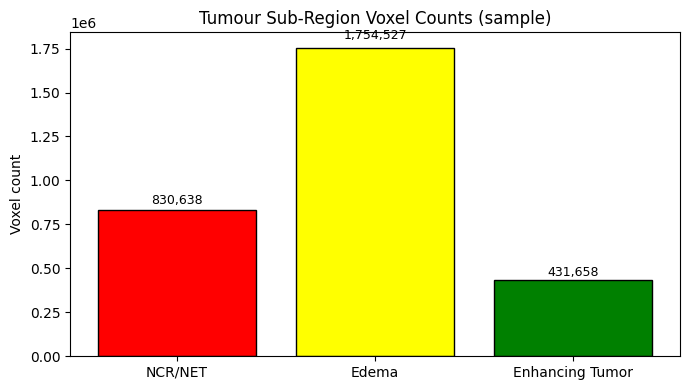

Phase 1 ✓


In [10]:
# ── Dataset-wide label distribution (sample 30 patients) ───────────
print("\nEstimating label distribution across 30 random patients …")
label_counts_total = {0: 0, 1: 0, 2: 0, 4: 0}
n_sample = min(30, len(train_patients))
sampled  = random.sample(train_patients, n_sample)
 
for pid in tqdm(sampled, desc="Scanning"):
    pdata = load_patient(pid)
    for lbl in [0, 1, 2, 4]:
        label_counts_total[lbl] += int((pdata["seg"] == lbl).sum())
 
total = sum(label_counts_total.values())
print(f"\n── Label Distribution ({n_sample} patients sampled) ──")
for lbl, cnt in label_counts_total.items():
    name = label_names.get(lbl, f"Label {lbl}")
    print(f"  {name:<20}: {cnt:>12,}  ({100*cnt/total:.4f}%)")
 
# Quick bar chart
fig, ax = plt.subplots(figsize=(7, 4))
names_plot  = [label_names[l] for l in [1, 2, 4]]
counts_plot = [label_counts_total[l] for l in [1, 2, 4]]   # exclude background
colors_plot = ["red", "yellow", "green"]
bars = ax.bar(names_plot, counts_plot, color=colors_plot, edgecolor="black")
ax.set_title("Tumour Sub-Region Voxel Counts (sample)", fontsize=12)
ax.set_ylabel("Voxel count")
for bar, cnt in zip(bars, counts_plot):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f"{cnt:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()
 
print("Phase 1 ✓")

## Phase 2: Pre Processing

In [11]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║            PHASE 2 — PREPROCESSING PIPELINE & DATASET CLASS             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
 
# ── Normalisation helpers ─────────────────────────────────────────
 
def zscore_normalize(volume: np.ndarray) -> np.ndarray:
    """
    Z-score normalise a single modality volume.
    Statistics are computed ONLY over non-zero (brain) voxels to avoid
    the skull-stripped background (value = 0) distorting the mean/std.
 
    Args:
        volume : np.ndarray  shape (H, W, D)
    Returns:
        normalised volume (same shape, float32); background stays 0.
    """
    brain_mask = volume > 0
    if brain_mask.sum() == 0:
        return volume.astype(np.float32)
    mean = volume[brain_mask].mean()
    std  = volume[brain_mask].std()
    if std < 1e-8:
        std = 1e-8
    norm = np.zeros_like(volume, dtype=np.float32)
    norm[brain_mask] = (volume[brain_mask] - mean) / std
    return norm
 
 
def build_target_mask(seg: np.ndarray) -> np.ndarray:
    """
    Convert BraTS integer segmentation → 3-channel binary mask.
 
    BraTS labels  : 0=background, 1=NCR/NET, 2=edema, 4=enhancing tumour
    Output channels (paper convention):
        ch 0 → Whole Tumour (WT)     = {1, 2, 4}
        ch 1 → Tumour Core  (TC)     = {1, 4}
        ch 2 → Enhancing Tumour (ET) = {4}
 
    Args:
        seg : np.ndarray  int16  shape (H, W, D)
    Returns:
        mask: np.ndarray  float32 shape (3, H, W, D)
    """
    mask = np.zeros((3, *seg.shape), dtype=np.float32)
    mask[0] = ((seg == 1) | (seg == 2) | (seg == 4)).astype(np.float32)  # WT
    mask[1] = ((seg == 1) | (seg == 4)).astype(np.float32)                # TC
    mask[2] = (seg == 4).astype(np.float32)                               # ET
    return mask

In [12]:
# ── Cell 2-B : Patch extraction helpers ──────────────────────────────────────
 
def random_crop_3d(image: np.ndarray,
                   mask:  np.ndarray,
                   patch_size: tuple = (PATCH_D, PATCH_H, PATCH_W),
                   foreground_prob: float = 0.80
                   ) -> tuple:
    """
    Extract a 3-D patch from image and mask with tumour-centred bias.
 
    With probability `foreground_prob`, the crop is centred on a random
    foreground (tumour) voxel.  Otherwise it is a fully random crop.
    This helps balance the severe class imbalance in BraTS.
 
    Args:
        image      : np.ndarray  float32  (4, H, W, D)   — 4 modalities stacked
        mask       : np.ndarray  float32  (3, H, W, D)   — 3-class binary mask
        patch_size : (pD, pH, pW)
        foreground_prob : probability of tumour-centred crop
 
    Returns:
        (image_patch, mask_patch) each with leading channel dim kept.
    """
    pD, pH, pW = patch_size
    _, H, W, D = image.shape
 
    # Safety: pad if volume is smaller than patch (shouldn't happen with BraTS)
    pad_D = max(0, pD - D)
    pad_H = max(0, pH - H)
    pad_W = max(0, pW - W)
    if pad_D or pad_H or pad_W:
        image = np.pad(image, ((0,0),(0,pad_H),(0,pad_W),(0,pad_D)))
        mask  = np.pad(mask,  ((0,0),(0,pad_H),(0,pad_W),(0,pad_D)))
        _, H, W, D = image.shape
 
    # Decide: foreground crop or random crop
    use_fg = (random.random() < foreground_prob)
 
    if use_fg:
        # Any tumour voxel across all 3 channels
        fg_voxels = np.argwhere(mask.any(axis=0))   # shape (N, 3): (h,w,d)
        if len(fg_voxels) > 0:
            centre = fg_voxels[random.randint(0, len(fg_voxels)-1)]
            h_c, w_c, d_c = centre
            # Clip so patch stays inside volume
            h0 = int(np.clip(h_c - pH//2, 0, H - pH))
            w0 = int(np.clip(w_c - pW//2, 0, W - pW))
            d0 = int(np.clip(d_c - pD//2, 0, D - pD))
        else:
            use_fg = False          # fallback if no foreground found
 
    if not use_fg:
        h0 = random.randint(0, H - pH)
        w0 = random.randint(0, W - pW)
        d0 = random.randint(0, D - pD)
 
    img_patch  = image[:, h0:h0+pH, w0:w0+pW, d0:d0+pD]
    mask_patch = mask[:,  h0:h0+pH, w0:w0+pW, d0:d0+pD]
    return img_patch, mask_patch
 
 
def center_crop_3d(image: np.ndarray,
                   mask:  np.ndarray,
                   patch_size: tuple = (PATCH_D, PATCH_H, PATCH_W)) -> tuple:
    """
    Centre-crop for validation — deterministic.
 
    Args:
        image : (4, H, W, D)
        mask  : (3, H, W, D)
    Returns:
        (image_patch, mask_patch)
    """
    pD, pH, pW = patch_size
    _, H, W, D = image.shape
 
    pad_D = max(0, pD - D)
    pad_H = max(0, pH - H)
    pad_W = max(0, pW - W)
    if pad_D or pad_H or pad_W:
        image = np.pad(image, ((0,0),(0,pad_H),(0,pad_W),(0,pad_D)))
        mask  = np.pad(mask,  ((0,0),(0,pad_H),(0,pad_W),(0,pad_D)))
        _, H, W, D = image.shape
 
    h0 = (H - pH) // 2
    w0 = (W - pW) // 2
    d0 = (D - pD) // 2
 
    return image[:, h0:h0+pH, w0:w0+pW, d0:d0+pD], \
           mask[:,  h0:h0+pH, w0:w0+pW, d0:d0+pD]

In [13]:
# ── Cell 2-C : Augmentation helpers ──────────────────────────────────────────
 
def augment_3d(image: np.ndarray, mask: np.ndarray) -> tuple:
    """
    Light 3-D augmentation (train only).  No augmentation on validation.
 
    Operations applied randomly:
      1. Random flip along each of the 3 spatial axes
      2. Random intensity scaling per modality  ×  U(0.9, 1.1)
      3. Random intensity shift  per modality   +  N(0, 0.1)
 
    Args:
        image : np.ndarray  float32  (4, H, W, D)
        mask  : np.ndarray  float32  (3, H, W, D)
    Returns:
        augmented (image, mask)
    """
    # Flip each axis with 50% probability
    # Axes: 1=H, 2=W, 3=D  (axis 0 is channels)
    for ax in [1, 2, 3]:
        if random.random() > 0.5:
            image = np.flip(image, axis=ax).copy()
            mask  = np.flip(mask,  axis=ax).copy()
 
    # Intensity scale + shift per modality
    for c in range(image.shape[0]):
        scale = random.uniform(0.9, 1.1)
        shift = random.gauss(0, 0.1)
        image[c] = image[c] * scale + shift
 
    return image, mask

In [14]:
# ── Cell 2-D : PyTorch Dataset ────────────────────────────────────────────────
 
class BraTS2020Dataset(Dataset):
    """
    PyTorch Dataset for BraTS 2020 brain tumour segmentation.
 
    Each __getitem__ call:
      1. Loads 4 NIfTI modalities + seg mask for one patient
      2. Z-score normalises each modality independently (brain voxels only)
      3. Converts integer seg labels → 3-channel binary mask
      4. Extracts a patch (random-foreground-biased for train, centre for val)
      5. Applies augmentation (train only)
      6. Returns (image_tensor, mask_tensor) as float32 torch.Tensor
 
    image_tensor : (4, pD, pH, pW)  — 4 modalities
    mask_tensor  : (3, pD, pH, pW)  — WT, TC, ET binary masks
    """
 
    def __init__(self,
                 patient_ids:    list,
                 base_dir:       str   = TRAIN_DIR,
                 patch_size:     tuple = (PATCH_D, PATCH_H, PATCH_W),
                 is_train:       bool  = True,
                 foreground_prob: float = 0.80):
        """
        Args:
            patient_ids     : list of patient folder names
            base_dir        : root directory containing patient folders
            patch_size      : (D, H, W) crop size
            is_train        : True → random crop + augmentation
                              False → centre crop, no augmentation
            foreground_prob : probability of tumour-centred crop (train only)
        """
        super().__init__()
        self.patient_ids      = patient_ids
        self.base_dir         = base_dir
        self.patch_size       = patch_size
        self.is_train         = is_train
        self.foreground_prob  = foreground_prob
 
    def __len__(self) -> int:
        return len(self.patient_ids)
 
    def __getitem__(self, idx: int) -> tuple:
            pid = self.patient_ids[idx]
    
            # ── 1. Load NIfTI files ───────────────────────────────────────────
            patient_path = os.path.join(self.base_dir, pid)
            modality_volumes = []
    
            for mod in MODALITIES:
                fname = f"{pid}_{mod}.nii"
                fpath = os.path.join(patient_path, fname)
                if not os.path.exists(fpath):
                    fpath += ".gz"
                vol = nib.load(fpath).get_fdata(dtype=np.float32)  # (H, W, D)
                modality_volumes.append(vol)
    
            # --- Robust Mask Loading (Fix for Patient 355) ---
            patient_files = os.listdir(patient_path)
            try:
                # Search for files containing 'seg' or 'segm' to handle naming outliers
                mask_filename = next(f for f in patient_files if 'seg' in f.lower())
                seg_path = os.path.join(patient_path, mask_filename)
            except StopIteration:
                raise FileNotFoundError(f"Could not find a segmentation file for {pid} in {patient_path}")
    
            # Load and ensure labels are processed correctly
            seg = nib.load(seg_path).get_fdata(dtype=np.float32).astype(np.int16)
    
            # ── 2. Normalise each modality independently ──────────────────────
            norm_volumes = [zscore_normalize(v) for v in modality_volumes]
    
            # ── 3. Stack → (4, H, W, D) & build 3-channel mask → (3, H, W, D) ─
            image = np.stack(norm_volumes, axis=0)   # (4, H, W, D)
            mask  = build_target_mask(seg)           # (3, H, W, D)
    
            # ── 4. Patch extraction ───────────────────────────────────────────
            if self.is_train:
                image, mask = random_crop_3d(image, mask,
                                             patch_size=self.patch_size,
                                             foreground_prob=self.foreground_prob)
            else:
                image, mask = center_crop_3d(image, mask, patch_size=self.patch_size)
    
            # ── 5. Augmentation (train only) ──────────────────────────────────
            if self.is_train:
                image, mask = augment_3d(image, mask)
    
            # ── 6. Numpy → Torch ──────────────────────────────────────────────
            image_tensor = torch.from_numpy(image.copy()).float()
            mask_tensor  = torch.from_numpy(mask.copy()).float()
    
            return image_tensor, mask_tensor, pid

In [15]:
# ── Cell 2-E : Build train / val splits and DataLoaders ──────────────────────
 
def build_dataloaders(train_patients: list,
                      batch_size:     int   = BATCH_SIZE,
                      num_workers:    int   = NUM_WORKERS,
                      train_frac:     float = TRAIN_FRAC,
                      patch_size:     tuple = (PATCH_D, PATCH_H, PATCH_W)
                      ) -> tuple:
    """
    Split train_patients 80/20, return (train_loader, val_loader, n_train, n_val).
    """
    n_total = len(train_patients)
    n_train = int(n_total * train_frac)
    n_val   = n_total - n_train
 
    # Deterministic split
    rng   = random.Random(SEED)
    pids  = train_patients.copy()
    rng.shuffle(pids)
    train_pids = pids[:n_train]
    val_pids   = pids[n_train:]
 
    train_dataset = BraTS2020Dataset(train_pids, TRAIN_DIR,
                                     patch_size=patch_size,
                                     is_train=True)
    val_dataset   = BraTS2020Dataset(val_pids,   TRAIN_DIR,
                                     patch_size=patch_size,
                                     is_train=False)
 
    train_loader = DataLoader(train_dataset,
                              batch_size=batch_size,
                              shuffle=True,
                              num_workers=num_workers,
                              pin_memory=True,
                              drop_last=True)
 
    val_loader   = DataLoader(val_dataset,
                              batch_size=batch_size,
                              shuffle=False,
                              num_workers=num_workers,
                              pin_memory=True,
                              drop_last=False)
 
    return train_loader, val_loader, n_train, n_val
 
 
train_loader, val_loader, n_train, n_val = build_dataloaders(train_patients)
 
print("=" * 55)
print(f"  Train patients      : {n_train}")
print(f"  Val   patients      : {n_val}")
print(f"  Train batches/epoch : {len(train_loader)}")
print(f"  Val   batches/epoch : {len(val_loader)}")
print("=" * 55)

  Train patients      : 295
  Val   patients      : 74
  Train batches/epoch : 147
  Val   batches/epoch : 37


In [16]:
# ── Cell 2-F : Verify one batch from the DataLoader ──────────────────────────
print("\nFetching one batch to verify shapes and dtypes …")
t0 = time.time()
 
# Grab first batch
images_batch, masks_batch, pids_batch = next(iter(train_loader))
 
elapsed = time.time() - t0
print(f"  Batch load time     : {elapsed:.2f}s")
print(f"  Image tensor shape  : {tuple(images_batch.shape)}")   # (B, 4, D, H, W)
print(f"  Mask  tensor shape  : {tuple(masks_batch.shape)}")    # (B, 3, D, H, W)
print(f"  Image dtype         : {images_batch.dtype}")
print(f"  Mask  dtype         : {masks_batch.dtype}")
print(f"  Patient IDs         : {list(pids_batch)}")
 
# Per-modality stats in the batch
print("\n── Per-modality batch stats ──")
print(f"{'Modality':<10} {'Min':>8} {'Max':>8} {'Mean':>10} {'Std':>10}")
print("-" * 48)
for i, mod in enumerate(MODALITIES):
    ch = images_batch[0, i]           # (D, H, W)
    brain = ch[ch != 0]
    if len(brain) > 0:
        print(f"{mod:<10} {ch.min().item():>8.3f} {ch.max().item():>8.3f} "
              f"{brain.mean().item():>10.4f} {brain.std().item():>10.4f}")
 
# Mask channel occupancy
print("\n── Mask channel occupancy (% active voxels) ──")
ch_names = ["WT", "TC", "ET"]
for i, name in enumerate(ch_names):
    pct = 100 * masks_batch[0, i].mean().item()
    print(f"  {name}: {pct:.4f}%")
 


Fetching one batch to verify shapes and dtypes …
  Batch load time     : 12.66s
  Image tensor shape  : (2, 4, 128, 128, 128)
  Mask  tensor shape  : (2, 3, 128, 128, 128)
  Image dtype         : torch.float32
  Mask  dtype         : torch.float32
  Patient IDs         : ['BraTS20_Training_279', 'BraTS20_Training_034']

── Per-modality batch stats ──
Modality        Min      Max       Mean        Std
------------------------------------------------
flair        -3.657    4.690    -0.0187     0.6624
t1           -5.622    6.617     0.0633     0.7016
t1ce         -4.753   11.098     0.0394     0.7376
t2           -2.255    4.027    -0.0762     0.7656

── Mask channel occupancy (% active voxels) ──
  WT: 7.7583%
  TC: 6.4385%
  ET: 0.0000%


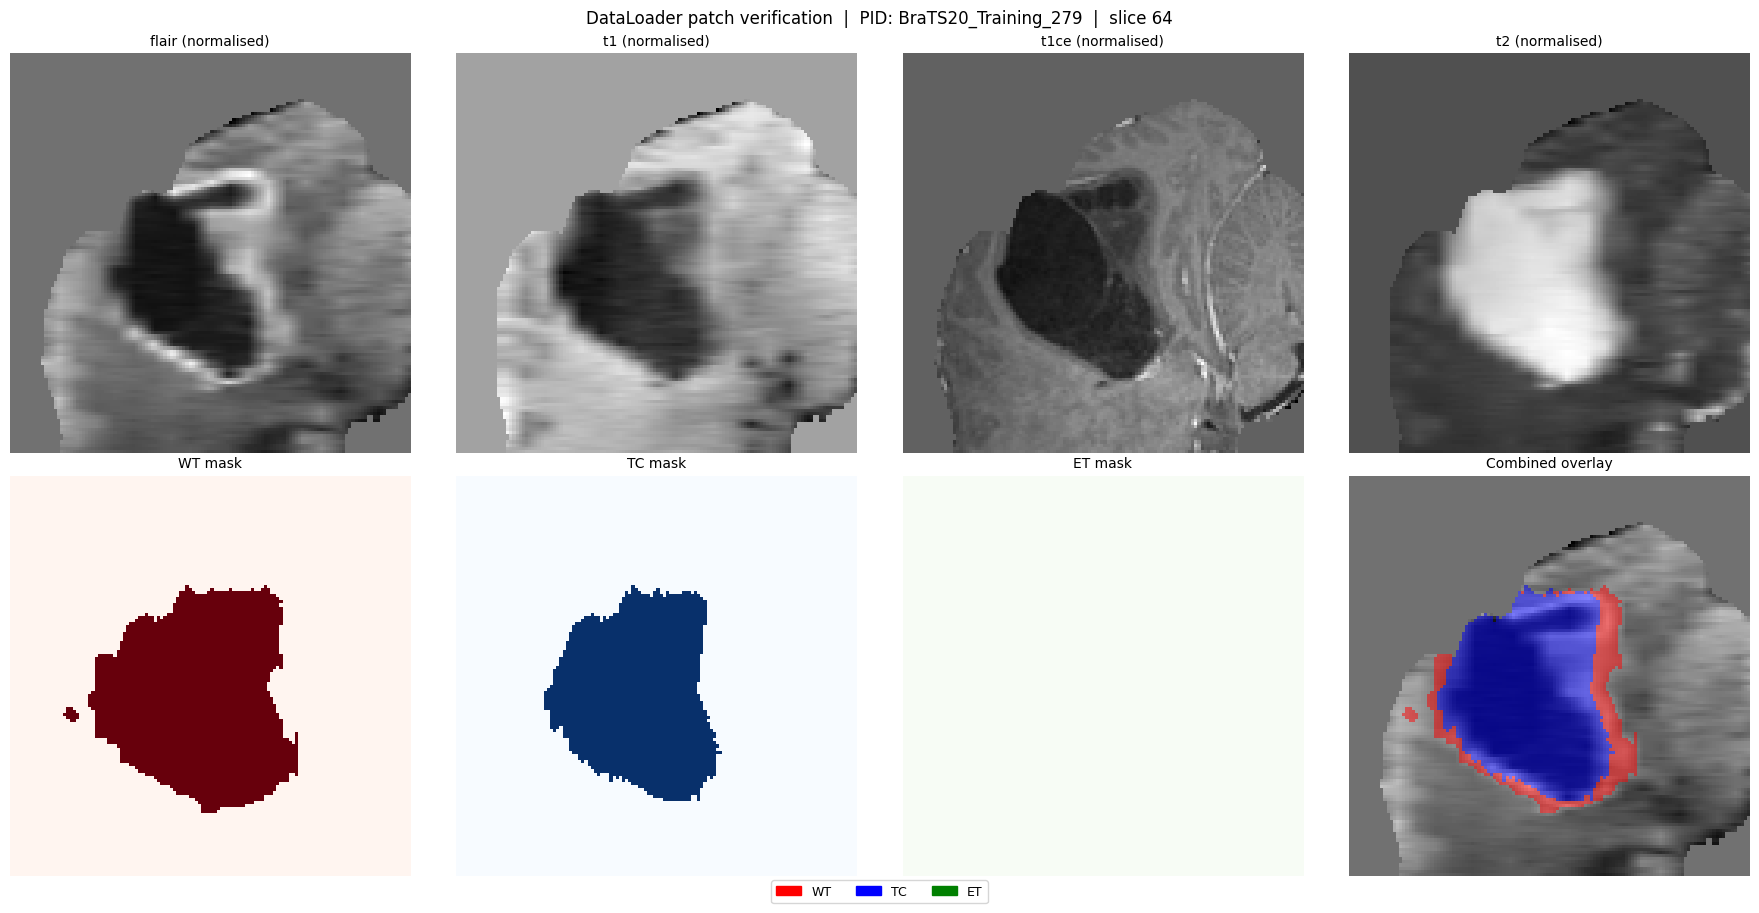

In [17]:
# ── Cell 2-G : Visualise a patch from the DataLoader ─────────────────────────
def visualize_batch_patch(image_t: torch.Tensor,
                          mask_t:  torch.Tensor,
                          pid:     str):
    """
    Quick visual check: show mid-slice of each modality + 3 mask channels.
 
    image_t : (4, D, H, W)   — single sample from batch[0]
    mask_t  : (3, D, H, W)
    """
    D = image_t.shape[1]
    mid = D // 2
 
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(f"DataLoader patch verification  |  PID: {pid}  |  slice {mid}",
                 fontsize=12)
 
    # Row 0: 4 modalities
    for i, mod in enumerate(MODALITIES):
        sl = image_t[i, mid].numpy()
        axes[0, i].imshow(sl, cmap="gray", origin="lower")
        axes[0, i].set_title(f"{mod} (normalised)", fontsize=10)
        axes[0, i].axis("off")
 
    # Row 1: 3 mask channels + overlay
    mask_colors = ["Reds", "Blues", "Greens"]
    ch_names    = ["WT mask", "TC mask", "ET mask"]
    for i in range(3):
        sl = mask_t[i, mid].numpy()
        axes[1, i].imshow(sl, cmap=mask_colors[i], origin="lower", vmin=0, vmax=1)
        axes[1, i].set_title(ch_names[i], fontsize=10)
        axes[1, i].axis("off")
 
    # Combined overlay on axes[1,3]
    flair_sl = image_t[0, mid].numpy()
    overlay  = np.zeros((*flair_sl.shape, 4), dtype=np.float32)
    if mask_t[0, mid].any():    # WT → red
        overlay[mask_t[0, mid].numpy() == 1] = [1, 0, 0, 0.5]
    if mask_t[1, mid].any():    # TC → blue
        overlay[mask_t[1, mid].numpy() == 1] = [0, 0, 1, 0.5]
    if mask_t[2, mid].any():    # ET → green
        overlay[mask_t[2, mid].numpy() == 1] = [0, 1, 0, 0.8]
 
    axes[1, 3].imshow(flair_sl, cmap="gray", origin="lower")
    axes[1, 3].imshow(overlay,  origin="lower")
    axes[1, 3].set_title("Combined overlay", fontsize=10)
    axes[1, 3].axis("off")
 
    patches = [
        mpatches.Patch(color="red",   label="WT"),
        mpatches.Patch(color="blue",  label="TC"),
        mpatches.Patch(color="green", label="ET"),
    ]
    fig.legend(handles=patches, loc="lower center", ncol=3,
               fontsize=9, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.show()
 
visualize_batch_patch(images_batch[0], masks_batch[0], pids_batch[0])

In [18]:
# ── Cell 2-H : Normalisation unit test ───────────────────────────────────────
print("\n── Normalisation sanity checks ──")
 
# Load a raw volume
test_vol = load_patient(train_patients[5])["flair"]
norm_vol = zscore_normalize(test_vol)
 
brain_raw  = test_vol[test_vol > 0]
brain_norm = norm_vol[norm_vol != 0]
 
print(f"  Raw  flair | mean={brain_raw.mean():.2f}  std={brain_raw.std():.2f}")
print(f"  Norm flair | mean={brain_norm.mean():.4f}  std={brain_norm.std():.4f}  "
      f"(should be ≈0 mean, ≈1 std)")
assert abs(brain_norm.mean()) < 0.05, "Mean is not close to 0 — check normalisation!"
assert abs(brain_norm.std()  - 1.0) < 0.05, "Std is not close to 1 — check normalisation!"
print("  ✓  Z-score normalisation passed")


── Normalisation sanity checks ──
  Raw  flair | mean=184.38  std=76.97
  Norm flair | mean=0.0000  std=1.0000  (should be ≈0 mean, ≈1 std)
  ✓  Z-score normalisation passed


In [19]:
# ── Cell 2-I : Label conversion unit test ─────────────────────────────────────
print("\n── Label conversion sanity checks ──")
test_seg  = load_patient(train_patients[0])["seg"]
test_mask = build_target_mask(test_seg)
 
# WT must contain everything TC contains
assert (test_mask[0] >= test_mask[1]).all(), "WT must ⊇ TC — FAILED"
# TC must contain everything ET contains
assert (test_mask[1] >= test_mask[2]).all(), "TC must ⊇ ET — FAILED"
# ET voxels must align with label=4 in original seg
assert (test_mask[2] == (test_seg == 4).astype(np.float32)).all(), \
    "ET channel mismatch — FAILED"
print("  ✓  Label conversion passed  (WT ⊇ TC ⊇ ET)")
 
print("\n" + "=" * 55)
print("  Phase 0  ✓  Complete")
print("  Phase 1  ✓  Complete")
print("  Phase 2  ✓  Complete")
print("  Ready for Phase 3 → Model Architecture")
print("=" * 55)
 


── Label conversion sanity checks ──
  ✓  Label conversion passed  (WT ⊇ TC ⊇ ET)

  Phase 0  ✓  Complete
  Phase 1  ✓  Complete
  Phase 2  ✓  Complete
  Ready for Phase 3 → Model Architecture


## Phase 3: HYBRID-DANet ARCHITECTURE

In [20]:
# ── Cell 3-A : Base Modules (DCB, RM, MCS) ───────────────────────────────────

class DCB(nn.Module):
    """Double Convolutional Block: GN -> Conv3x3 -> ReLU -> Conv3x3 -> GN -> ReLU"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)

class RM(nn.Module):
    """Residual Module: BN+ReLU -> Conv -> BN+ReLU -> Conv -> Conv + skip"""
    def __init__(self, ch):
        super().__init__()
        self.bn1 = nn.BatchNorm3d(ch)
        self.conv1 = nn.Conv3d(ch, ch, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm3d(ch)
        self.conv2 = nn.Conv3d(ch, ch, kernel_size=3, padding=1)
        self.conv3 = nn.Conv3d(ch, ch, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        res = x
        out = self.conv1(self.relu(self.bn1(x)))
        out = self.conv2(self.relu(self.bn2(out)))
        out = self.conv3(out)
        return out + res

class MCS(nn.Module):
    """Multi-Channel Multi-Scale Module"""
    def __init__(self, ch):
        super().__init__()
        self.squeeze = nn.Conv3d(ch, ch//2, kernel_size=1)
        self.branch1 = nn.Conv3d(ch//2, ch//4, kernel_size=1)
        self.branch2 = nn.Conv3d(ch//2, ch//4, kernel_size=3, padding=1)
        self.restore = nn.Conv3d(ch//2, ch, kernel_size=1)
        self.gn = nn.GroupNorm(8, ch)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x_sq = self.relu(self.squeeze(x))
        b1 = self.branch1(x_sq)
        b2 = self.branch2(x_sq)
        out = torch.cat([b1, b2], dim=1)
        return self.relu(self.gn(self.restore(out)))

In [21]:
# ── Cell 3-B : HWADA Attention Module ────────────────────────────────────────

class HWADA(nn.Module):
    """Hybrid Weight Alignment with Multi-Dilated Attention"""
    def __init__(self, g_ch, x_ch, inter_ch, dilations):
        super().__init__()
        d1, d2 = dilations
        # Scheme branch 1
        self.g1 = nn.Sequential(nn.Conv3d(g_ch, inter_ch, 1), nn.Conv3d(inter_ch, inter_ch, 3, padding=d1, dilation=d1))
        self.x1 = nn.Sequential(nn.Conv3d(x_ch, inter_ch, 1), nn.Conv3d(inter_ch, inter_ch, 3, padding=d1, dilation=d1))
        # Scheme branch 2
        self.g2 = nn.Sequential(nn.Conv3d(g_ch, inter_ch, 1), nn.Conv3d(inter_ch, inter_ch, 3, padding=d2, dilation=d2))
        self.x2 = nn.Sequential(nn.Conv3d(x_ch, inter_ch, 1), nn.Conv3d(inter_ch, inter_ch, 3, padding=d2, dilation=d2))
        
        self.psi = nn.Sequential(nn.Conv3d(inter_ch, 1, 1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        # Match g's spatial size to x if needed (due to upsampling)
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(g, size=x.shape[2:], mode='trilinear', align_corners=False)
        
        s1 = self.g1(g) + self.x1(x)
        s2 = self.g2(g) + self.x2(x)
        attn = self.psi(self.relu(s1 + s2))
        return x * attn


In [22]:
# ── Cell 3-C : Full HybridDANet Assembly (FIXED CHANNELS) ──────────────────────

class HybridDANet(nn.Module):
    def __init__(self, in_ch=4, out_ch=3):
        super().__init__()
        # Encoder
        self.e1 = nn.Sequential(DCB(in_ch, 16), RM(16), MCS(16))
        self.d1 = nn.Conv3d(16, 32, 2, stride=2)
        self.e2 = nn.Sequential(DCB(32, 32), RM(32), MCS(32))
        self.d2 = nn.Conv3d(32, 64, 2, stride=2)
        self.e3 = nn.Sequential(DCB(64, 64), RM(64), MCS(64))
        self.d3 = nn.Conv3d(64, 128, 2, stride=2)
        self.e4 = nn.Sequential(DCB(128, 128), RM(128), MCS(128))
        self.d4 = nn.Conv3d(128, 256, 2, stride=2)

        # Bottleneck
        self.b = nn.Sequential(DCB(256, 256), RM(256), MCS(256))

        # HWADA Attention on Skips
        # Gating channels (g_ch) must match the output of the Up-convolution layers below
        self.h4 = HWADA(g_ch=128, x_ch=128, inter_ch=64, dilations=(1, 7))
        self.h3 = HWADA(g_ch=64,  x_ch=64,  inter_ch=32, dilations=(1, 5))
        self.h2 = HWADA(g_ch=32,  x_ch=32,  inter_ch=16, dilations=(1, 2))
        self.h1 = HWADA(g_ch=16,  x_ch=16,  inter_ch=8,  dilations=(1, 1))

        # Decoder
        self.up4 = nn.ConvTranspose3d(256, 128, 2, stride=2)
        self.dec4 = nn.Sequential(DCB(256, 128), RM(128), MCS(128))
        
        self.up3 = nn.ConvTranspose3d(128, 64, 2, stride=2)
        self.dec3 = nn.Sequential(DCB(128, 64), RM(64), MCS(64))
        
        self.up2 = nn.ConvTranspose3d(64, 32, 2, stride=2)
        self.dec2 = nn.Sequential(DCB(64, 32), RM(32), MCS(32))
        
        self.up1 = nn.ConvTranspose3d(32, 16, 2, stride=2)
        self.dec1 = nn.Sequential(DCB(32, 16), RM(16), MCS(16))
        
        self.final = nn.Conv3d(16, out_ch, 1)

    def forward(self, x):
        # Encoder
        s1 = self.e1(x)
        s2 = self.e2(self.d1(s1))
        s3 = self.e3(self.d2(s2))
        s4 = self.e4(self.d3(s3))
        
        # Bottleneck
        feat = self.b(self.d4(s4))
        
        # Decoder 4
        up4 = self.up4(feat)
        h4 = self.h4(up4, s4)
        feat = self.dec4(torch.cat([h4, up4], dim=1))
        
        # Decoder 3
        up3 = self.up3(feat)
        h3 = self.h3(up3, s3)
        feat = self.dec3(torch.cat([h3, up3], dim=1))
        
        # Decoder 2
        up2 = self.up2(feat)
        h2 = self.h2(up2, s2)
        feat = self.dec2(torch.cat([h2, up2], dim=1))
        
        # Decoder 1
        up1 = self.up1(feat)
        h1 = self.h1(up1, s1)
        feat = self.dec1(torch.cat([h1, up1], dim=1))
        
        return self.final(feat)

## PHASE 4 — LOSS FUNCTIONS

In [23]:
class CombinedLoss(nn.Module):
    """Combined Focal Tversky Loss + Generalized Dice Loss"""
    def __init__(self, alpha=0.7, beta=0.3, gamma=4/3):
        super().__init__()
        self.alpha, self.beta, self.gamma = alpha, beta, gamma

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        # Flatten
        pred = pred.view(-1)
        target = target.view(-1)
        
        # Focal Tversky
        tp = (pred * target).sum()
        fp = (pred * (1 - target)).sum()
        fn = ((1 - pred) * target).sum()
        tversky = (tp + 1e-6) / (tp + self.alpha*fn + self.beta*fp + 1e-6)
        ft_loss = torch.pow((1 - tversky), 1/self.gamma)
        
        # Dice Loss
        dice = (2 * tp + 1e-6) / (pred.sum() + target.sum() + 1e-6)
        
        return ft_loss + (1 - dice)

## PHASE 5 — TRAINING SETUP

In [24]:
# Initialize Model
model = HybridDANet().to(device)
if n_gpus > 1:
    model = nn.DataParallel(model)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
criterion = CombinedLoss()
scaler = torch.cuda.amp.GradScaler() # Mixed Precision

# Metric Tracker
def get_dice(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    dice_scores = []
    for i in range(3): # WT, TC, ET
        p, t = pred[:, i], target[:, i]
        inter = (p * t).sum()
        dice_scores.append(((2 * inter + 1e-6) / (p.sum() + t.sum() + 1e-6)).item())
    return dice_scores

## PHASE 6, 7 & 8 — TRAINING LOOP & VISUALIZATION

In [67]:
EPOCHS = 35
best_dice = 0
patience = 8  # Number of epochs to wait for improvement
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    model.train()
    train_losses = []
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for img, mask, _ in pbar:
        img, mask = img.to(device), mask.to(device)
        
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            pred = model(img)
            loss = criterion(pred, mask)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_losses.append(loss.item())
        pbar.set_postfix(loss=np.mean(train_losses))

    # --- Validation ---
    model.eval()
    val_dice = []
    with torch.no_grad():
        for img, mask, _ in val_loader:
            img, mask = img.to(device), mask.to(device)
            pred = model(img)
            val_dice.append(get_dice(pred, mask))
            
    mean_val_dice = np.mean(val_dice, axis=0)
    avg_dice = np.mean(mean_val_dice)
    print(f"Validation Dice - WT: {mean_val_dice[0]:.4f} TC: {mean_val_dice[1]:.4f} ET: {mean_val_dice[2]:.4f} Avg: {avg_dice:.4f}")
    
    # --- Model Saving & Early Stopping Logic ---
    if avg_dice > best_dice:
        best_dice = avg_dice
        epochs_without_improvement = 0  # Reset counter on improvement
        
        # Correctly save weights even if using nn.DataParallel
        model_to_save = model.module if hasattr(model, 'module') else model
        
        save_path = "hybrid_danet_best.pth"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model_to_save.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_dice': best_dice,
        }, save_path)
        print(f"✅ Best model saved with Dice: {best_dice:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"⚠️ No improvement for {epochs_without_improvement} epoch(s).")
    
    if epochs_without_improvement >= patience:
        print(f"🛑 Early stopping triggered after {epoch + 1} epochs.")
        break

# Final save for the last state
torch.save(model.state_dict(), "hybrid_danet_final.pth")
print("Training Complete. Models saved to /kaggle/working/")

Epoch 1:   0%|          | 0/147 [00:00<?, ?it/s]

Validation Dice - WT: 0.1658 TC: 0.0025 ET: 0.0171 Avg: 0.0618
✅ Best model saved with Dice: 0.0618


Epoch 2:   0%|          | 0/147 [00:00<?, ?it/s]

Validation Dice - WT: 0.1684 TC: 0.0029 ET: 0.0171 Avg: 0.0628
✅ Best model saved with Dice: 0.0628


Epoch 3:   0%|          | 0/147 [00:00<?, ?it/s]

...

Validation Dice - WT: 0.6386 TC: 0.4395 ET: 0.0217 Avg: 0.3666
⚠️ No improvement for 1 epoch(s).


Epoch 34:   0%|          | 0/147 [00:00<?, ?it/s]

Validation Dice - WT: 0.6351 TC: 0.4388 ET: 0.0218 Avg: 0.3652
⚠️ No improvement for 2 epoch(s).


Epoch 35:   0%|          | 0/147 [00:00<?, ?it/s]

Validation Dice - WT: 0.6953 TC: 0.4720 ET: 0.0218 Avg: 0.3964
✅ Best model saved with Dice: 0.3964
Training Complete. Models saved to /kaggle/working/


## Resume Training

In [ ]:
import os
import torch
import torch.nn as nn
from collections import OrderedDict
from tqdm import tqdm
import numpy as np

# 1. Update this path to wherever your uploaded weights are located!
checkpoint_path = "/kaggle/input/models/muhammadwajdan/brain-tumor-segmentation-hybrid-danet/pytorch/phase-135/1/hybrid_danet_best.pth" 

print("Initializing model...")
# 2. Create fresh model on CPU first
model = HybridDANet(in_ch=4, out_ch=3)

# 3. Safely Load Weights (Bypassing PyTorch 2.6 security check)
print(f"Loading weights from {checkpoint_path}...")
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

# Extract state dict and clean 'module.' prefixes if they exist
state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k[7:] if k.startswith('module.') else k
    new_state_dict[name] = v

model.load_state_dict(new_state_dict)
print("✅ Weights loaded!")

# 4. Move to Multi-GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.device_count() > 1:
    print(f"🚀 Dual GPU detected. Parallelizing...")
    model = nn.DataParallel(model)
model = model.to(device)

# 5. Restore Optimizer & Epoch State
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
if 'optimizer_state_dict' in checkpoint:
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Grab saved stats, default to 35 and your last best score if missing
start_epoch = checkpoint.get('epoch', 35) 
best_dice = checkpoint.get('best_dice', 0.3964) 
TOTAL_EPOCHS = 50
patience = 8
epochs_without_improvement = 0

print(f"▶️ Resuming training from Epoch {start_epoch + 1} to {TOTAL_EPOCHS}. Previous Best Avg Dice: {best_dice:.4f}")

# 6. The Training Loop (Epochs 36 to 50)
for epoch in range(start_epoch, TOTAL_EPOCHS):
    model.train()
    train_losses = []
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{TOTAL_EPOCHS}")
    for img, mask, _ in pbar:
        img, mask = img.to(device), mask.to(device)
        
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            pred = model(img)
            loss = criterion(pred, mask)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_losses.append(loss.item())
        pbar.set_postfix(loss=np.mean(train_losses))

    # --- Validation ---
    model.eval()
    val_dice = []
    with torch.no_grad():
        for img, mask, _ in val_loader:
            img, mask = img.to(device), mask.to(device)
            pred = model(img)
            val_dice.append(get_dice(pred, mask))
            
    mean_val_dice = np.mean(val_dice, axis=0)
    avg_dice = np.mean(mean_val_dice)
    print(f"Validation Dice - WT: {mean_val_dice[0]:.4f} TC: {mean_val_dice[1]:.4f} ET: {mean_val_dice[2]:.4f} Avg: {avg_dice:.4f}")
    
    # --- Save & Early Stop Logic ---
    if avg_dice > best_dice:
        best_dice = avg_dice
        epochs_without_improvement = 0 
        
        model_to_save = model.module if isinstance(model, nn.DataParallel) else model
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model_to_save.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_dice': best_dice,
        }, "/kaggle/working/hybrid_danet_best_resumed.pth")
        print(f"✅ New best model saved! (Dice: {best_dice:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"⚠️ No improvement for {epochs_without_improvement} epoch(s).")
    
    if epochs_without_improvement >= patience:
        print(f"🛑 Early stopping triggered. Model has plateaued.")
        break

# Final save for safety
model_to_save = model.module if isinstance(model, nn.DataParallel) else model
torch.save(model_to_save.state_dict(), "/kaggle/working/hybrid_danet_final_ep50.pth")
print("🎉 Continuation Training Complete!")

Initializing model...
Loading weights from /kaggle/input/models/muhammadwajdan/brain-tumor-segmentation-hybrid-danet/pytorch/phase-135/1/hybrid_danet_best.pth...
✅ Weights loaded!
🚀 Dual GPU detected. Parallelizing...
▶️ Resuming training from Epoch 36 to 50. Previous Best Avg Dice: 0.3964


Epoch 36/50: 100%|██████████| 147/147 [03:50<00:00,  1.57s/it, loss=1.83]


Validation Dice - WT: 0.7096 TC: 0.4917 ET: 0.0264 Avg: 0.4092
✅ New best model saved! (Dice: 0.4092)


Epoch 37/50: 100%|██████████| 147/147 [04:08<00:00,  1.69s/it, loss=1.83]


Validation Dice - WT: 0.7094 TC: 0.4955 ET: 0.0293 Avg: 0.4114
✅ New best model saved! (Dice: 0.4114)


...

Epoch 43/50: 100%|██████████| 147/147 [03:52<00:00,  1.58s/it, loss=1.8]


Validation Dice - WT: 0.7772 TC: 0.4752 ET: 0.1679 Avg: 0.4734
✅ New best model saved! (Dice: 0.4734)


Epoch 44/50: 100%|██████████| 147/147 [03:51<00:00,  1.58s/it, loss=1.77]


Validation Dice - WT: 0.8328 TC: 0.5040 ET: 0.2495 Avg: 0.5288
✅ New best model saved! (Dice: 0.5288)


Epoch 45/50:  18%|█▊        | 27/147 [00:47<02:51,  1.43s/it, loss=1.74]

## Download model

In [42]:
import os
from IPython.display import FileLink

# 1. Change the working directory directly to where the file is
os.chdir(r'/kaggle/working')

# 2. ✅ THE FIX: Pass ONLY the file name, not the absolute path!
print("Click below to download your 75-epoch model:")
display(FileLink(r'hybrid_danet_best_ep75.pth'))

Click below to download your 75-epoch model:


/kaggle/working/hybrid_danet_best_ep75.pth

## TESTING

## 35 Epochs

Loading weights from /kaggle/working/hybrid_danet_best.pth...
✅ Weights loaded successfully!

Running inference on BraTS20_Training_368...


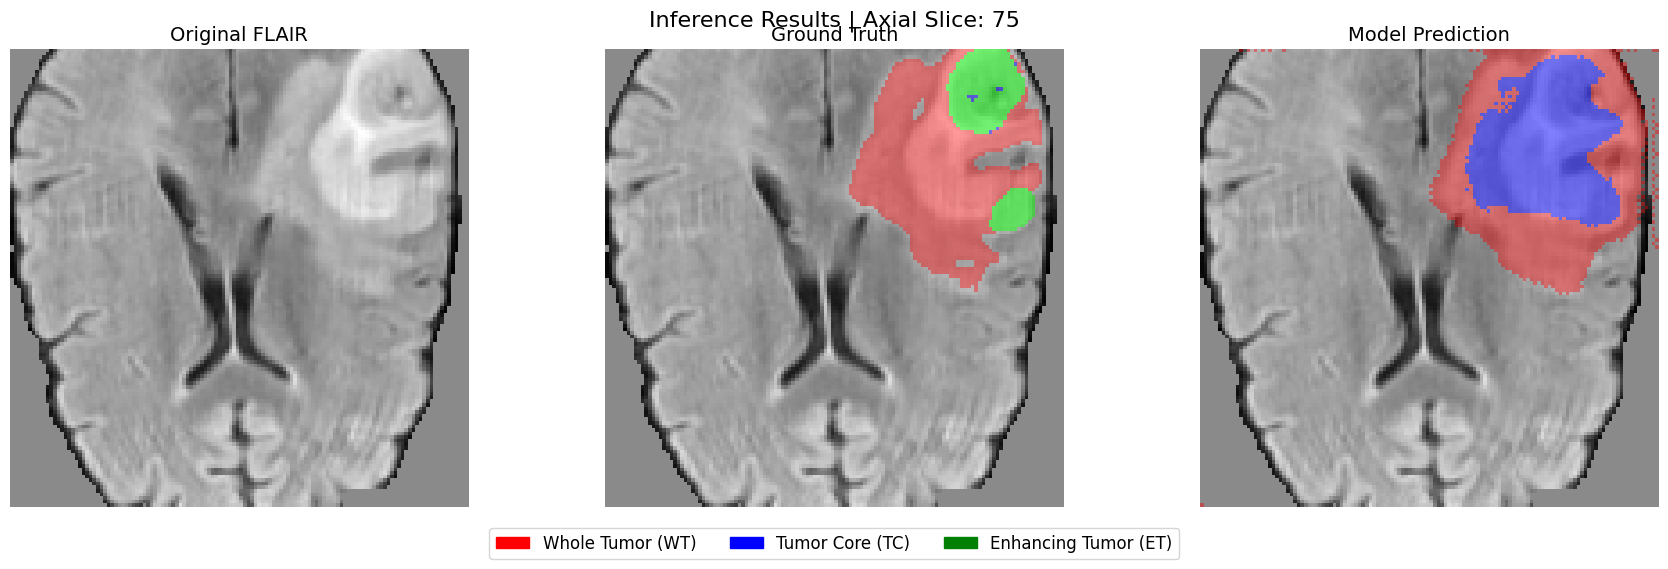

In [73]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import OrderedDict

# ── 1. Helper to safely load weights ─────────
def load_checkpoint(model, checkpoint_path, device):
    print(f"Loading weights from {checkpoint_path}...")
    
    # ✅ FIX: Added weights_only=False to bypass PyTorch 2.6 security block
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract the state dict (we saved it inside a dictionary)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    
    # If model was saved with nn.DataParallel but loaded without it (or vice versa)
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k  # remove 'module.' prefix
        new_state_dict[name] = v
        
    model.load_state_dict(new_state_dict)
    model.to(device)
    model.eval()
    print("✅ Weights loaded successfully!")
    return model

# ── 2. Inference Function (UPDATED THRESHOLDS) ──────────────────────────────
def predict_3d_volume(model, patient_id, base_dir, device):
    patient_path = os.path.join(base_dir, patient_id)
    
    images = []
    for mod in MODALITIES:
        fpath = os.path.join(patient_path, f"{patient_id}_{mod}.nii")
        if not os.path.exists(fpath): fpath += ".gz"
        vol = nib.load(fpath).get_fdata(dtype=np.float32)
        images.append(zscore_normalize(vol))
        
    img_array = np.stack(images, axis=0)
    
    _, H, W, D = img_array.shape
    pD, pH, pW = PATCH_D, PATCH_H, PATCH_W
    h0, w0, d0 = (H - pH) // 2, (W - pW) // 2, (D - pD) // 2
    
    img_crop = img_array[:, h0:h0+pH, w0:w0+pW, d0:d0+pD]
    img_tensor = torch.from_numpy(img_crop).unsqueeze(0).float().to(device)
    
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            pred = model(img_tensor)
            pred_sigmoid = torch.sigmoid(pred).cpu().numpy()[0]
            
            # ✅ THE FIX: Custom confidence thresholds!
            # We demand 85% confidence for ET to prevent the "Green Flood"
            pred_wt = pred_sigmoid[0] > 0.50
            pred_tc = pred_sigmoid[1] > 0.60
            pred_et = pred_sigmoid[2] > 0.85 
            
            pred_binary = np.stack([pred_wt, pred_tc, pred_et], axis=0)
            
    files = os.listdir(patient_path)
    mask_file = next(f for f in files if 'seg' in f.lower())
    seg = nib.load(os.path.join(patient_path, mask_file)).get_fdata(dtype=np.float32).astype(np.int16)
    
    seg_crop = seg[h0:h0+pH, w0:w0+pW, d0:d0+pD]
    gt_mask = build_target_mask(seg_crop)
    
    return img_crop[0], gt_mask, pred_binary

# ── 3. Visualization Function (UPDATED OPACITY) ─────────────────────────────
def plot_inference(flair, gt_mask, pred_mask, slice_idx=None):
    if slice_idx is None:
        slice_idx = flair.shape[2] // 2
        
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Inference Results | Axial Slice: {slice_idx}", fontsize=16)
    
    flair_sl = flair[:, :, slice_idx].T
    gt_sl = gt_mask[:, :, :, slice_idx]     
    pred_sl = pred_mask[:, :, :, slice_idx] 
    
    def create_overlay(mask_3ch):
        overlay = np.zeros((*flair_sl.shape, 4), dtype=np.float32)
        # ✅ THE FIX: Balanced alpha/transparency so colors mix instead of hide
        if mask_3ch[0].any(): overlay[mask_3ch[0].T == 1] = [1, 0, 0, 0.4] # Red
        if mask_3ch[1].any(): overlay[mask_3ch[1].T == 1] = [0, 0, 1, 0.5] # Blue
        if mask_3ch[2].any(): overlay[mask_3ch[2].T == 1] = [0, 1, 0, 0.5] # Green
        return overlay

    axes[0].imshow(flair_sl, cmap="gray", origin="lower")
    axes[0].set_title("Original FLAIR", fontsize=14)
    axes[0].axis("off")
    
    axes[1].imshow(flair_sl, cmap="gray", origin="lower")
    axes[1].imshow(create_overlay(gt_sl), origin="lower")
    axes[1].set_title("Ground Truth", fontsize=14)
    axes[1].axis("off")
    
    axes[2].imshow(flair_sl, cmap="gray", origin="lower")
    axes[2].imshow(create_overlay(pred_sl), origin="lower")
    axes[2].set_title("Model Prediction", fontsize=14)
    axes[2].axis("off")
    
    patches = [
        mpatches.Patch(color="red", label="Whole Tumor (WT)"),
        mpatches.Patch(color="blue", label="Tumor Core (TC)"),
        mpatches.Patch(color="green", label="Enhancing Tumor (ET)"),
    ]
    fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=12, bbox_to_anchor=(0.5, 0.05))
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()
# ── 4. EXECUTE TEST (FIXED) ─────────────────────────────────────────────────
# Initialize a fresh model wrapper
test_model = HybridDANet(in_ch=4, out_ch=3)
test_model = load_checkpoint(test_model, "/kaggle/working/hybrid_danet_best.pth", device)

# FIX: We MUST use a patient from the training directory because the 
# official validation directory does not contain ground truth masks.
# Let's grab a patient from near the end of the list (likely in your 20% val split)
test_patient = train_patients[-2] 
print(f"\nRunning inference on {test_patient}...")

# FIX: Changed VAL_DIR to TRAIN_DIR
flair_crop, gt_mask, pred_mask = predict_3d_volume(test_model, test_patient, TRAIN_DIR, device)

# Find a slice that actually contains a tumor in the ground truth
z_profiles = np.where(gt_mask[0].any(axis=(0,1)))[0]
best_slice = z_profiles[len(z_profiles)//2] if len(z_profiles) > 0 else PATCH_D // 2

# Plot!
plot_inference(flair_crop, gt_mask, pred_mask, slice_idx=best_slice)

## 75 EPOCHS

Loading weights from /kaggle/working/hybrid_danet_best_ep75.pth...
✅ Weights loaded successfully!

Running inference on BraTS20_Training_368...


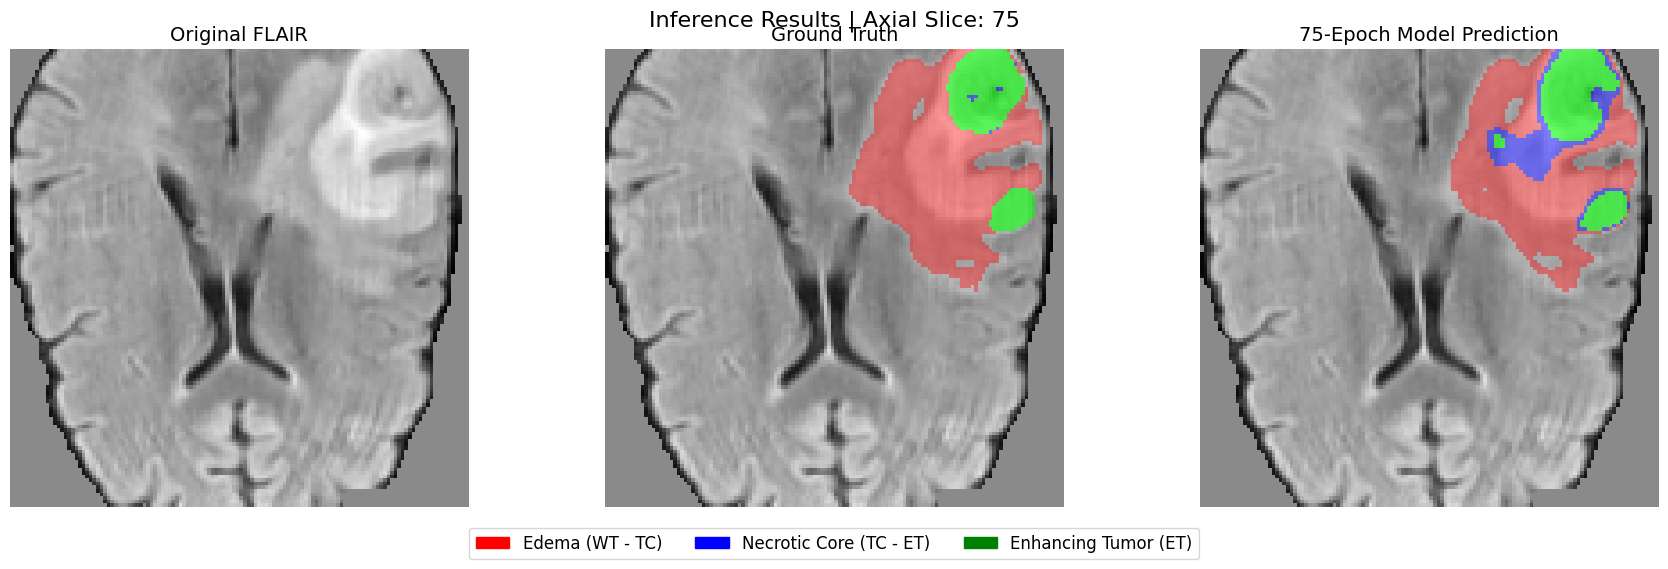

In [44]:
import os
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import OrderedDict

# ── 1. Helper to safely load weights ─────────
def load_checkpoint(model, checkpoint_path, device):
    print(f"Loading weights from {checkpoint_path}...")
    
    # ✅ Bypass PyTorch 2.6 security block
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract the state dict (we saved it inside a dictionary)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    
    # If model was saved with nn.DataParallel but loaded without it
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k  # remove 'module.' prefix
        new_state_dict[name] = v
        
    model.load_state_dict(new_state_dict)
    model.to(device)
    model.eval()
    print("✅ Weights loaded successfully!")
    return model

# ── 2. Inference Function (HIERARCHICAL LOGIC) ──────────────────────────────
def predict_3d_volume(model, patient_id, base_dir, device):
    patient_path = os.path.join(base_dir, patient_id)
    
    images = []
    for mod in MODALITIES:
        fpath = os.path.join(patient_path, f"{patient_id}_{mod}.nii")
        if not os.path.exists(fpath): fpath += ".gz"
        vol = nib.load(fpath).get_fdata(dtype=np.float32)
        images.append(zscore_normalize(vol))
        
    img_array = np.stack(images, axis=0)
    
    _, H, W, D = img_array.shape
    pD, pH, pW = PATCH_D, PATCH_H, PATCH_W
    h0, w0, d0 = (H - pH) // 2, (W - pW) // 2, (D - pD) // 2
    
    img_crop = img_array[:, h0:h0+pH, w0:w0+pW, d0:d0+pD]
    img_tensor = torch.from_numpy(img_crop).unsqueeze(0).float().to(device)
    
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            pred = model(img_tensor)
            pred_sigmoid = torch.sigmoid(pred).cpu().numpy()[0]
            
            # ✅ THE FIX: Apply Strict Biological Hierarchy
            # 1. WT can be anything above 50%
            pred_wt = pred_sigmoid[0] > 0.50 
            
            # 2. TC must be > 60% AND it MUST fall inside the WT footprint
            pred_tc = (pred_sigmoid[1] > 0.60) & pred_wt 
            
            # 3. ET must be > 65% AND it MUST fall inside the TC footprint
            pred_et = (pred_sigmoid[2] > 0.65) & pred_tc 
            
            pred_binary = np.stack([pred_wt, pred_tc, pred_et], axis=0)
            
    files = os.listdir(patient_path)
    mask_file = next(f for f in files if 'seg' in f.lower())
    seg = nib.load(os.path.join(patient_path, mask_file)).get_fdata(dtype=np.float32).astype(np.int16)
    
    seg_crop = seg[h0:h0+pH, w0:w0+pW, d0:d0+pD]
    gt_mask = build_target_mask(seg_crop)
    
    return img_crop[0], gt_mask, pred_binary

# ── 3. Visualization Function (DISJOINT RENDERING) ──────────────────────────
def plot_inference(flair, gt_mask, pred_mask, slice_idx=None):
    if slice_idx is None:
        slice_idx = flair.shape[2] // 2
        
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Inference Results | Axial Slice: {slice_idx}", fontsize=16)
    
    flair_sl = flair[:, :, slice_idx].T
    gt_sl = gt_mask[:, :, :, slice_idx]     
    pred_sl = pred_mask[:, :, :, slice_idx] 
    
    def create_overlay(mask_3ch):
        overlay = np.zeros((*flair_sl.shape, 4), dtype=np.float32)
        
        # ✅ THE FIX: Force arrays to boolean so the '~' operator works safely!
        wt = mask_3ch[0].T.astype(bool)
        tc = mask_3ch[1].T.astype(bool)
        et = mask_3ch[2].T.astype(bool)
        
        edema_only = wt & ~tc      # Red (WT minus the core)
        core_only = tc & ~et       # Blue (Core minus the enhancing part)
        enhancing = et             # Green (Just the enhancing part)

        # Apply colors using the boolean masks directly
        if edema_only.any(): overlay[edema_only] = [1, 0, 0, 0.4] 
        if core_only.any(): overlay[core_only] = [0, 0, 1, 0.5] 
        if enhancing.any(): overlay[enhancing] = [0, 1, 0, 0.6] 
        
        return overlay

    axes[0].imshow(flair_sl, cmap="gray", origin="lower")
    axes[0].set_title("Original FLAIR", fontsize=14)
    axes[0].axis("off")
    
    axes[1].imshow(flair_sl, cmap="gray", origin="lower")
    axes[1].imshow(create_overlay(gt_sl), origin="lower")
    axes[1].set_title("Ground Truth", fontsize=14)
    axes[1].axis("off")
    
    axes[2].imshow(flair_sl, cmap="gray", origin="lower")
    axes[2].imshow(create_overlay(pred_sl), origin="lower")
    axes[2].set_title("75-Epoch Model Prediction", fontsize=14)
    axes[2].axis("off")
    
    patches = [
        mpatches.Patch(color="red", label="Edema (WT - TC)"),
        mpatches.Patch(color="blue", label="Necrotic Core (TC - ET)"),
        mpatches.Patch(color="green", label="Enhancing Tumor (ET)"),
    ]
    fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=12, bbox_to_anchor=(0.5, 0.05))
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

# ── 4. EXECUTE TEST (UPDATED FOR 50 EPOCHS) ─────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize a fresh model wrapper
test_model = HybridDANet(in_ch=4, out_ch=3)

# ✅ Point to the newly saved 50-epoch resumed weights!
test_model = load_checkpoint(test_model, "/kaggle/working/hybrid_danet_best_ep75.pth", device)

# Grab a patient from the training directory
test_patient = train_patients[-2] 
print(f"\nRunning inference on {test_patient}...")

flair_crop, gt_mask, pred_mask = predict_3d_volume(test_model, test_patient, TRAIN_DIR, device)

# Find a slice that actually contains a tumor in the ground truth
z_profiles = np.where(gt_mask[0].any(axis=(0,1)))[0]
best_slice = z_profiles[len(z_profiles)//2] if len(z_profiles) > 0 else PATCH_D // 2

# Plot!
plot_inference(flair_crop, gt_mask, pred_mask, slice_idx=best_slice)

🚀 Running batch inference on 3 random patients...

Processing Patient: BraTS20_Training_331


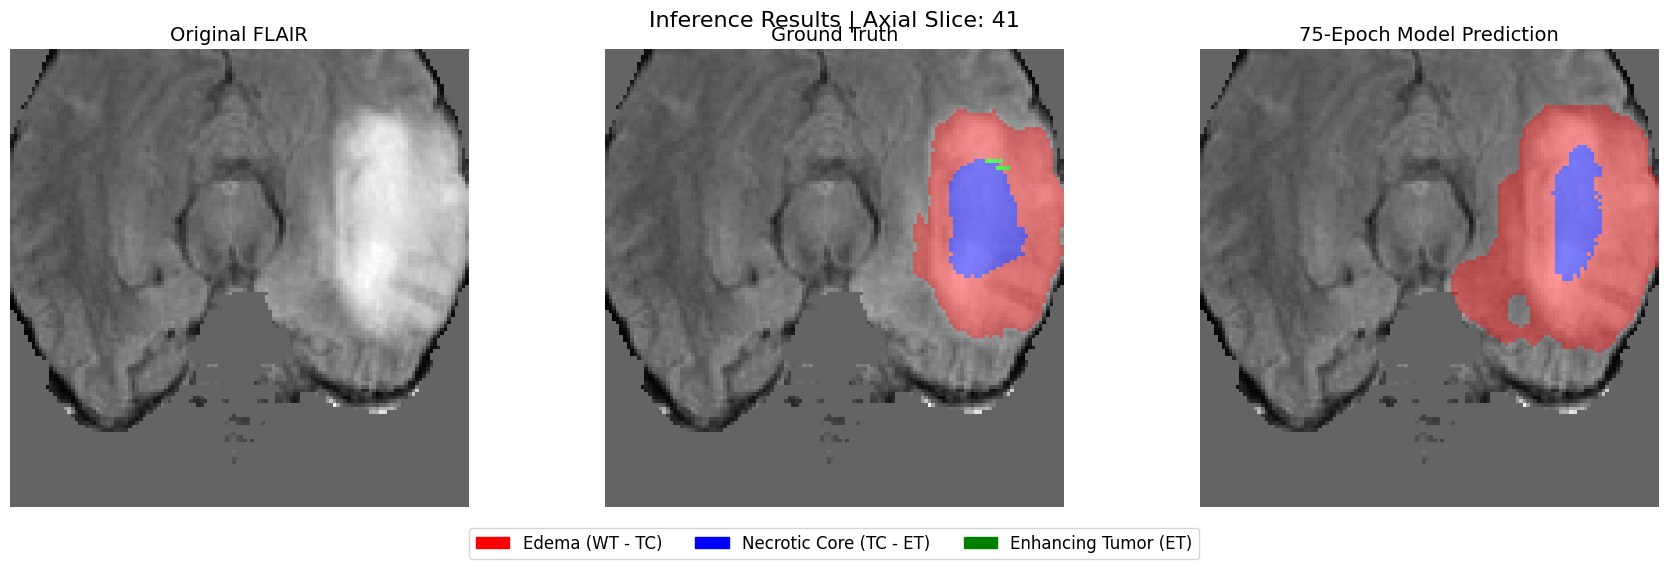


Processing Patient: BraTS20_Training_296


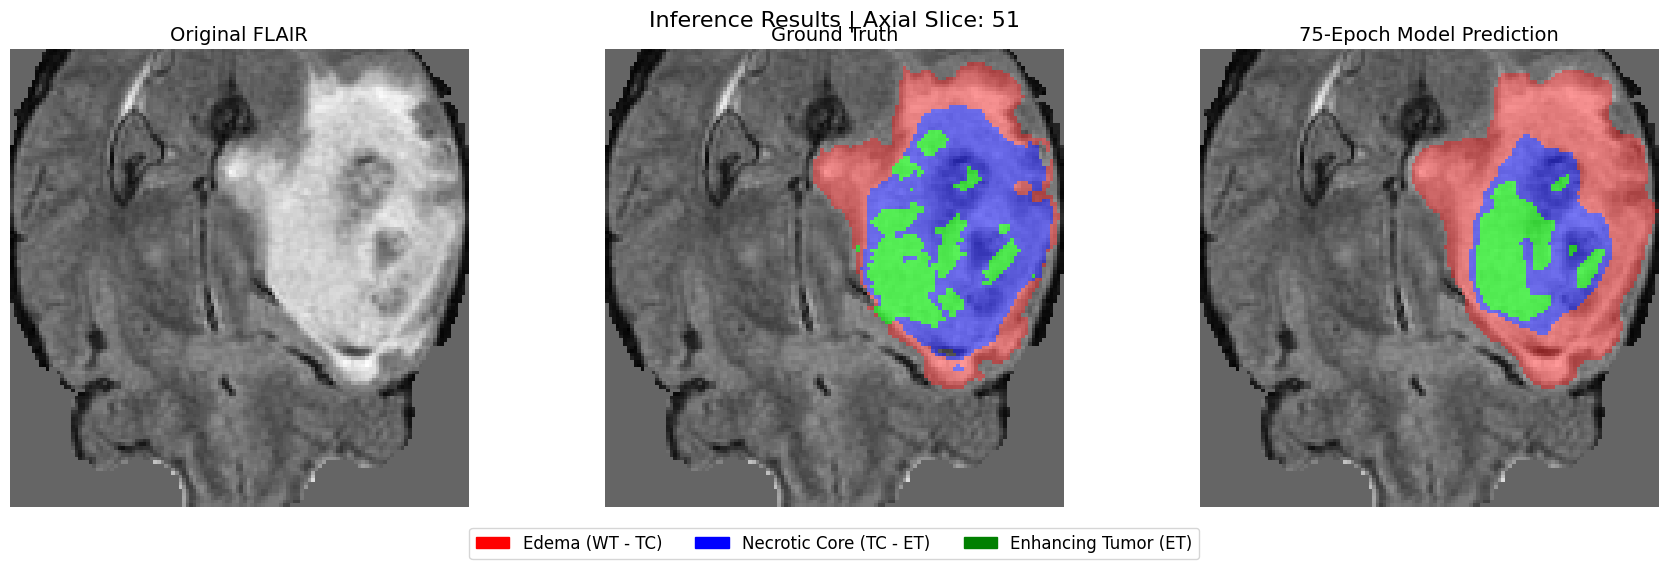


Processing Patient: BraTS20_Training_316


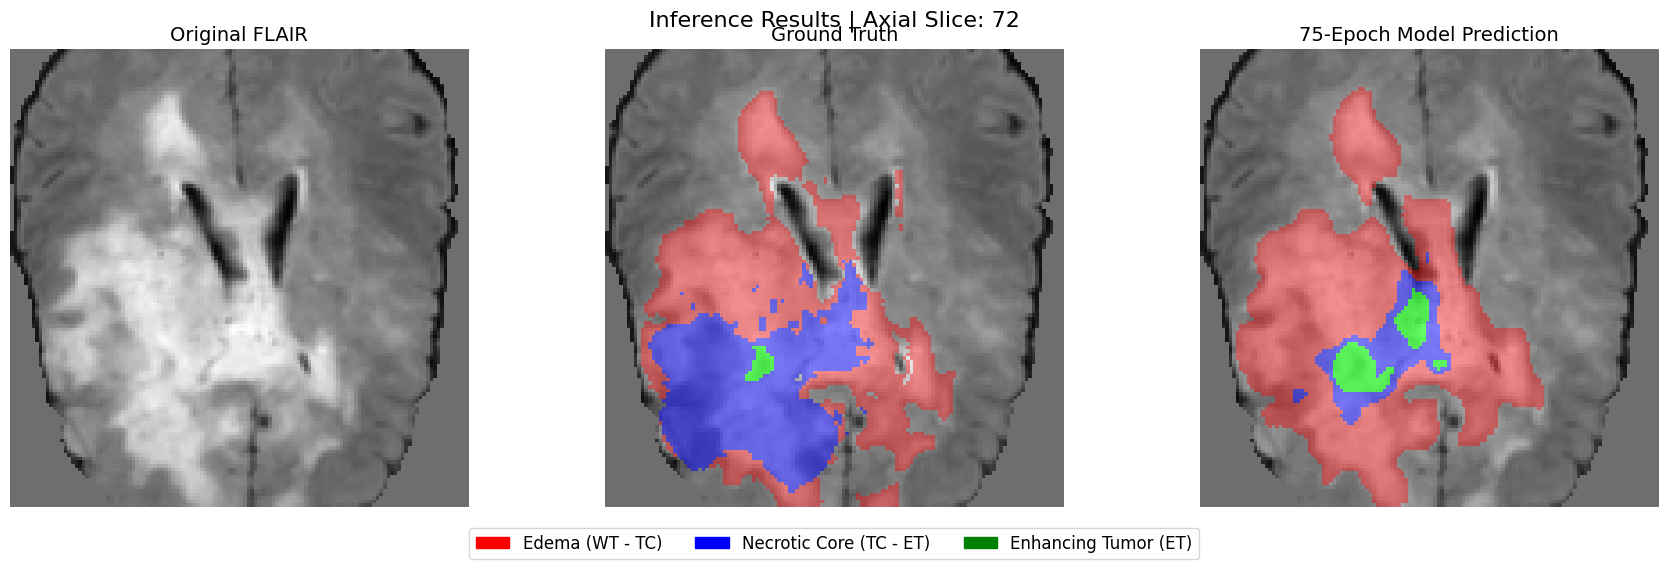

In [45]:
import random

# ── 5. BATCH INFERENCE TEST ─────────────────────────────────────────────────
# Pick 3 random patients from the last 20% of your dataset 
# (to ensure the model hasn't memorized them during early epochs)
num_samples = 3
val_split_start = int(len(train_patients) * 0.8)

# Safely grab random patients
sample_patients = random.sample(train_patients[val_split_start:], num_samples)

print(f"🚀 Running batch inference on {num_samples} random patients...")

for patient in sample_patients:
    print(f"\n" + "="*50)
    print(f"Processing Patient: {patient}")
    print("="*50)
    
    # 1. Run inference
    flair_crop, gt_mask, pred_mask = predict_3d_volume(test_model, patient, TRAIN_DIR, device)
    
    # 2. Find a slice that actually contains a tumor in the ground truth
    z_profiles = np.where(gt_mask[0].any(axis=(0,1)))[0]
    
    if len(z_profiles) > 0:
        # Pick a slice right in the meaty center of the tumor
        best_slice = z_profiles[len(z_profiles)//2] 
    else:
        # Fallback if the random crop missed the tumor
        print("⚠️ No tumor found in this specific crop, showing center slice.")
        best_slice = PATCH_D // 2 
        
    # 3. Plot!
    plot_inference(flair_crop, gt_mask, pred_mask, slice_idx=best_slice)

In [46]:
import torch
import numpy as np
from tqdm import tqdm

# ── 1. Load the 75-Epoch Model ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eval_model = HybridDANet(in_ch=4, out_ch=3)

# Use your saved 75 epoch weights
eval_model = load_checkpoint(eval_model, "/kaggle/working/hybrid_danet_best_ep75.pth", device)
eval_model.eval() # Strictly set to evaluation mode

# ── 2. Dice Score Function ──────────────────────────────────────────────────
def calculate_batch_dice(pred_binary, target_mask):
    """
    Calculates Dice score for a batch of predictions.
    Formula: (2 * intersection) / (prediction_area + target_area)
    """
    # Flatten the spatial dimensions to easily calculate intersection/union
    # Assuming shape is [Batch, Class, Depth, Height, Width] or [Batch, Class, Height, Width]
    axes = tuple(range(2, pred_binary.ndim)) 
    
    intersection = np.sum(pred_binary * target_mask, axis=axes)
    union = np.sum(pred_binary, axis=axes) + np.sum(target_mask, axis=axes)
    
    # Add a tiny epsilon (1e-5) to prevent division by zero if a mask is empty
    dice = (2. * intersection + 1e-5) / (union + 1e-5)
    return dice # Returns array of shape [Batch, 3]

# ── 3. The Full Evaluation Loop ─────────────────────────────────────────────
print("\n🚀 Starting full evaluation on the unseen validation dataset...")

wt_scores = []
tc_scores = []
et_scores = []

with torch.no_grad():
    # Iterate through every batch in the validation loader
    for img, mask, _ in tqdm(val_loader, desc="Evaluating"):
        img = img.to(device)
        mask_np = mask.cpu().numpy() # Ground truth mask
        
        # Mixed precision inference for speed
        with torch.cuda.amp.autocast():
            pred = eval_model(img)
            pred_sigmoid = torch.sigmoid(pred).cpu().numpy()
            
        # ✅ Apply our successful Biological Hierarchy logic to the whole batch!
        # 1. WT > 50%
        pred_wt = pred_sigmoid[:, 0] > 0.50 
        
        # 2. TC > 60% AND inside WT
        pred_tc = (pred_sigmoid[:, 1] > 0.60) & pred_wt 
        
        # 3. ET > 65% AND inside TC
        pred_et = (pred_sigmoid[:, 2] > 0.65) & pred_tc 
        
        # Stack back into [Batch, 3, ...] shape
        pred_binary = np.stack([pred_wt, pred_tc, pred_et], axis=1)
        
        # Calculate Dice for this batch
        batch_dice = calculate_batch_dice(pred_binary, mask_np)
        
        # Store scores
        wt_scores.extend(batch_dice[:, 0])
        tc_scores.extend(batch_dice[:, 1])
        et_scores.extend(batch_dice[:, 2])

# ── 4. Print the Final Report ───────────────────────────────────────────────
mean_wt = np.mean(wt_scores)
mean_tc = np.mean(tc_scores)
mean_et = np.mean(et_scores)
overall_avg = np.mean([mean_wt, mean_tc, mean_et])

print("\n" + "="*50)
print("🏆 FINAL VALIDATION METRICS (75 EPOCHS)")
print("="*50)
print(f"Whole Tumor (WT) Dice:     {mean_wt:.4f}  ({mean_wt * 100:.1f}%)")
print(f"Tumor Core (TC) Dice:      {mean_tc:.4f}  ({mean_tc * 100:.1f}%)")
print(f"Enhancing Tumor (ET) Dice: {mean_et:.4f}  ({mean_et * 100:.1f}%)")
print("-" * 50)
print(f"Overall Average Dice:      {overall_avg:.4f}  ({overall_avg * 100:.1f}%)")
print("="*50)

Loading weights from /kaggle/working/hybrid_danet_best_ep75.pth...
✅ Weights loaded successfully!

🚀 Starting full evaluation on the unseen validation dataset...


Evaluating: 100%|██████████| 37/37 [01:05<00:00,  1.76s/it]


🏆 FINAL VALIDATION METRICS (75 EPOCHS)
Whole Tumor (WT) Dice:     0.8804  (88.0%)
Tumor Core (TC) Dice:      0.7202  (72.0%)
Enhancing Tumor (ET) Dice: 0.6318  (63.2%)
--------------------------------------------------
Overall Average Dice:      0.7441  (74.4%)


In [48]:
import torch
import numpy as np
from tqdm import tqdm
from scipy.ndimage import distance_transform_edt, generate_binary_structure, binary_erosion

# ── 1. Helper Function: 95th Percentile Hausdorff Distance ──────────────────
def compute_hd95(pred, target):
    """Calculates the 95th percentile Hausdorff Distance using scipy."""
    if np.count_nonzero(pred) == 0 and np.count_nonzero(target) == 0:
        return 0.0 # Both empty: perfect match
    if np.count_nonzero(pred) == 0 or np.count_nonzero(target) == 0:
        return np.nan # One empty: distance is undefined, return NaN to exclude from average

    # Get the boundaries of the masks
    struct = generate_binary_structure(pred.ndim, 1)
    pred_border = pred ^ binary_erosion(pred, structure=struct)
    target_border = target ^ binary_erosion(target, structure=struct)

    # Compute shortest distances from prediction to target, and target to prediction
    dt_target = distance_transform_edt(~target_border)
    dt_pred = distance_transform_edt(~pred_border)
    
    dist_pred_to_target = dt_target[pred_border]
    dist_target_to_pred = dt_pred[target_border]

    # Combine and get 95th percentile
    if dist_pred_to_target.size == 0 or dist_target_to_pred.size == 0:
        return np.nan
    
    return max(np.percentile(dist_pred_to_target, 95), np.percentile(dist_target_to_pred, 95))

# ── 2. Helper Function: Calculate All Paper Metrics ─────────────────────────
def calculate_all_metrics(pred, target):
    """Calculates Dice, Sensitivity, Specificity, and HD95 for a single class array."""
    eps = 1e-5
    
    # Flatten arrays for boolean logic
    p = pred.flatten().astype(bool)
    t = target.flatten().astype(bool)
    
    TP = np.sum(p & t)
    FP = np.sum(p & ~t)
    FN = np.sum(~p & t)
    TN = np.sum(~p & ~t)
    
    dice = (2. * TP + eps) / (2. * TP + FP + FN + eps)
    sensitivity = (TP + eps) / (TP + FN + eps)
    specificity = (TN + eps) / (TN + FP + eps)
    
    # Only compute HD95 if dealing with 3D or 2D spatial patches
    hd95 = compute_hd95(pred.astype(bool), target.astype(bool))
    
    return dice, sensitivity, specificity, hd95

# ── 3. Initialize Model & Dictionaries ──────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eval_model = HybridDANet(in_ch=4, out_ch=3)
eval_model = load_checkpoint(eval_model, "/kaggle/working/hybrid_danet_best_ep75.pth", device)
eval_model.eval()

print("\n🚀 Starting full multi-metric evaluation on the validation dataset...")

# Dictionaries to store scores. 0=WT, 1=TC, 2=ET
results = {
    'WT': {'dice': [], 'sens': [], 'spec': [], 'hd95': []},
    'TC': {'dice': [], 'sens': [], 'spec': [], 'hd95': []},
    'ET': {'dice': [], 'sens': [], 'spec': [], 'hd95': []}
}
class_names = ['WT', 'TC', 'ET']

# ── 4. The Evaluation Loop ──────────────────────────────────────────────────
with torch.no_grad():
    for img, mask, _ in tqdm(val_loader, desc="Evaluating"):
        img = img.to(device)
        mask_np = mask.cpu().numpy()
        
        with torch.cuda.amp.autocast():
            pred = eval_model(img)
            pred_sigmoid = torch.sigmoid(pred).cpu().numpy()
            
        # Apply Biological Hierarchy
        pred_wt = pred_sigmoid[:, 0] > 0.50 
        pred_tc = (pred_sigmoid[:, 1] > 0.60) & pred_wt 
        pred_et = (pred_sigmoid[:, 2] > 0.65) & pred_tc 
        
        pred_binary = np.stack([pred_wt, pred_tc, pred_et], axis=1)
        
        # Calculate metrics for each item in the batch, for each class
        batch_size = pred_binary.shape[0]
        for b in range(batch_size):
            for c, c_name in enumerate(class_names):
                p = pred_binary[b, c]
                t = mask_np[b, c]
                
                dice, sens, spec, hd95 = calculate_all_metrics(p, t)
                
                results[c_name]['dice'].append(dice)
                results[c_name]['sens'].append(sens)
                results[c_name]['spec'].append(spec)
                if not np.isnan(hd95):
                    results[c_name]['hd95'].append(hd95)

# ── 5. Print the Final Formatted Table ──────────────────────────────────────
# Compute means
final = {}
for c_name in class_names:
    final[c_name] = {
        'dice': np.mean(results[c_name]['dice']),
        'sens': np.mean(results[c_name]['sens']),
        'spec': np.mean(results[c_name]['spec']),
        'hd95': np.mean(results[c_name]['hd95'])
    }

print("\n" + "="*80)
print(f"{'Method':<16} | {'Dice':<20} | {'Sensitivity':<20} | {'Specificity':<20} | {'Hausdorff95':<20}")
print(f"{'':<16} | {'WT':<5} {'TC':<5} {'ET':<6} | {'WT':<5} {'TC':<5} {'ET':<6} | {'WT':<5} {'TC':<5} {'ET':<6} | {'WT':<5} {'TC':<5} {'ET':<6}")
print("-" * 80)

# Format the row just like the paper
print(f"{'My Hybrid-DANet':<16} | "
      f"{final['WT']['dice']:.3f} {final['TC']['dice']:.3f} {final['ET']['dice']:.3f}  | "
      f"{final['WT']['sens']:.3f} {final['TC']['sens']:.3f} {final['ET']['sens']:.3f}  | "
      f"{final['WT']['spec']:.3f} {final['TC']['spec']:.3f} {final['ET']['spec']:.3f}  | "
      f"{final['WT']['hd95']:.2f} {final['TC']['hd95']:.2f} {final['ET']['hd95']:.2f}")
print("="*80)

Loading weights from /kaggle/working/hybrid_danet_best_ep75.pth...
✅ Weights loaded successfully!

🚀 Starting full multi-metric evaluation on the validation dataset...


Evaluating: 100%|██████████| 37/37 [02:29<00:00,  4.05s/it]


Method           | Dice                 | Sensitivity          | Specificity          | Hausdorff95         
                 | WT    TC    ET     | WT    TC    ET     | WT    TC    ET     | WT    TC    ET    
--------------------------------------------------------------------------------
My Hybrid-DANet  | 0.880 0.720 0.632  | 0.902 0.764 0.770  | 0.996 0.998 0.997  | 13.97 11.36 9.58
